# Portefeuille des élus du Congrès — spécification mathématique
**Reconstruction, classement, stratégie de copie et ajustement au marché**

Réutilise le pipeline de données du `05`, avec la **combinaison inter-membres en parts**
(NAV continue, buy-and-hold autofinancé) et
l'**ajustement par le marché** ($\beta$, $\alpha$, ratio d'appraisal).

Notations : $i$ = ticker, $t$ = jour de bourse ($t$, $t_{\text{appr}}$ et les seuils $t_{10}$, $t_{21}$
désignent la statistique de Student — le contexte tranche), $P_i(t)$ = cours de clôture.

> **Génération 2 (2026-08-11)** — le socle (chargement, prix, parts, mesures, pondérations,
> Ledoit-Wolf, carte commissions→secteurs) est importé du paquet
> [`tools/membre`](../tools/membre/__init__.py), extrait de ce notebook. La table rejouée est
> **la table courante du pipeline** : `owner_n`, le nom canonique et les commissions (table
> annexe) viennent du pipeline — plus aucun re-nettoyage local. Toutes les cellules d'analyse et
> de **validation** sont conservées et re-vérifient le reste indépendamment ; l'état antérieur
> (table v1 du 04/07) reste dans git.

## 0. Données (nettoyage transactionnel fait en amont)
Table canonique source-primaire + panel de prix `prices_v2` avec garde-fou anti-corruption Yahoo.
Périmètre : `traded` ∈ [2013 ; 2026] — 743 trades exécutés en 2013 (déclarés dans des dépôts 2014+) sont gardés,
36 séries de rendement démarrent donc avant 2014 ; chaque classement « à fin $Y$ » utilise tout l'historique $\le 31/12/Y$.

In [1]:
# ══ AMORÇAGE — le socle vient de tools/membre (extrait de CE notebook) ══
# Génération 2 : la table COURANTE du pipeline ; conventions membre : tools/membre/__init__.py.
%matplotlib inline
import pandas as pd, numpy as np, glob, os
import matplotlib.pyplot as plt
import sys; sys.path.insert(0, "..")
from tools.membre import donnees as mdon, moteur as mmot, mesure as mmes

MCTX = mdon.charger_membre()
BASE, PRICES, CLEAN = str(mdon.DOSSIER), str(mdon.PRICES), str(mdon.CLEAN)
CLEAN15 = CLEAN
df, spy, cal, r_spy = MCTX.df, MCTX.spy, MCTX.cal, MCTX.r_spy
prices, need, missing, corrompus, n0 = MCTX.prices, MCTX.need, MCTX.missing, MCTX.corrompus, MCTX.n0

# les noms historiques du notebook, adossés au contexte MCTX (wf_ret est défini au §2 : les
# wrappers le lisent à l'appel)
def eff_price(tk, d):      return mmot.eff_price(MCTX, tk, d)
def member_shares(g):      return mmot.member_shares(MCTX, g)
def daily_return(N):       return mmot.daily_return(MCTX, N)
def info_ratio(r):         return mmes.info_ratio(MCTX, r)
def alpha_beta(r):         return mmes.alpha_beta(MCTX, r)
stats = mmes.stats

# §9-§10 : fenêtre point-in-time, covariance, GMV/ERC, Ledoit-Wolf
def _fenetre_pit(bids, tR):  return mmot.fenetre_pit(wf_ret, bids, tR)
def _sigmas_pit(bids, tR):   return mmot.sigmas_pit(wf_ret, bids, tR)
def _cov_pit(bids, tR):      return mmot.cov_pit(wf_ret, bids, tR)
_gmv_from_cov, _erc_from_cov = mmot.gmv_from_cov, mmot.erc_from_cov
def w_equal(bids, tR):   return mmot.w_equal(wf_ret, bids, tR)
def w_invvol(bids, tR):  return mmot.w_invvol(wf_ret, bids, tR)
def w_gmv(bids, tR):     return mmot.w_gmv(wf_ret, bids, tR)
def w_erc(bids, tR):     return mmot.w_erc(wf_ret, bids, tR)
CovarianceMatrixRecipes = mmot.CovarianceMatrixRecipes
NUMBER_WORKING_DAYS, RISK_WINDOW_MIN = mmot.NUMBER_WORKING_DAYS, mmot.RISK_WINDOW_MIN
_TARGETS = mmot.TARGETS_LW
def _cov_pit_shrunk(bids, tR, target): return mmot.cov_pit_shrunk(wf_ret, bids, tR, target)

𝒯^brut (fenêtré, avant prix — table brute) : 134,417 trades | 372 membres | 4,607 tickers
clean (exploitable) : 118,316 trades | tickers avec prix 3,286 | sans prix 0 | corrompus 0 | jetés au chargement 0


In [2]:
print(f"aperçu de la table canonique : 5 des {len(df)} trades (1 ligne = 1 transaction déclarée)")
df.head()

aperçu de la table canonique : 5 des 118316 trades (1 ligne = 1 transaction déclarée)


,bioguide_id,name,ticker,op,traded,size_usd
0,G000563,Bob Gibbs,INTC,buy,2014-12-30,8000.5
1,G000563,Bob Gibbs,B,sell,2014-12-23,8000.5
2,G000563,Bob Gibbs,AAPL,buy,2014-12-30,8000.5
3,F000462,Lois Frankel,MMM,sell,2014-12-10,8000.5
4,F000462,Lois Frankel,XOM,sell,2014-12-03,8000.5


## 1. Reconstruction du portefeuille d'un membre
- **Achat** $\to$ parts, au 1er jour coté $\ge$ date de transaction : $q = \dfrac{\text{montant}}{P_i(\tau)},\ \tau=\min\{t\ge \texttt{traded}\}$
  (trade ignoré si le ticker ne cote pas encore à $\tau$ — cas rare).
- **Vente** $\to$ retire des parts (short interdit) : $q^- = \min(\text{montant}/P_i,\ \text{parts détenues})$.
- **Détentions cumulées** : $n_i(t) = \sum_{\text{achats}\le t} q - \sum_{\text{ventes}\le t} q^-$.
- **Valeur** : $V(t) = \sum_i n_i(t)\,P_i(t)$.

In [3]:
# Membre pris en exemple pour TOUTES les illustrations (constante, définie UNE fois ; les démos l'APPLIQUENT).
# ⚠️ filtre par bioguide_id, PAS par nom : certains élus portent plusieurs variantes de nom
#    (ex. « Barbara J. Comstock » ET « Barbara J Honorable Comstock ») -> le nom exact rate des trades.
DEMO = "Nancy Pelosi"
DEMO_BID = df.loc[df["name"] == DEMO, "bioguide_id"].iloc[0]

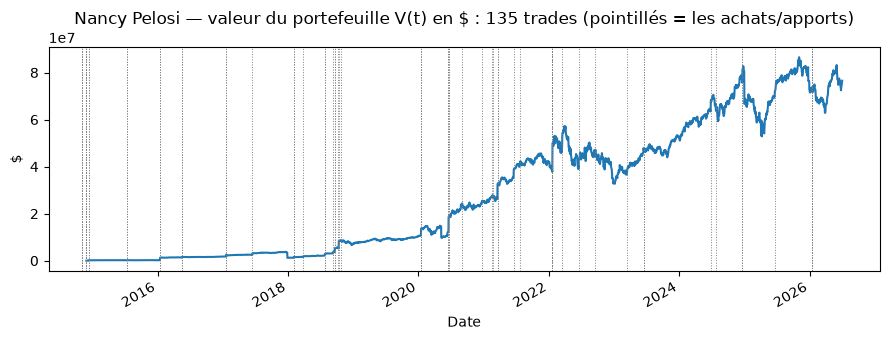

In [4]:
# Démo AUTO-SUFFISANTE : la VALEUR V(t) saute à chaque achat (apports + performance mélangés)
g_demo = df[df["bioguide_id"] == DEMO_BID]
Nm = member_shares(g_demo)
V = (Nm * pd.DataFrame({tk: prices[tk] for tk in Nm.columns})).sum(axis=1)
Va = V[Nm.sum(axis=1) > 0]
ax = Va.plot(figsize=(9, 3.5), color="tab:blue")
for d in g_demo.loc[g_demo["op"] == "buy", "traded"]:
    ax.axvline(d, color="gray", ls=":", lw=0.7)
ax.set_title(f"{DEMO} — valeur du portefeuille V(t) en $ : {len(g_demo)} trades (pointillés = les achats/apports)")
ax.set_ylabel("$"); plt.tight_layout(); plt.show()

In [5]:
# Démo AUTO-SUFFISANTE : le tableau N des parts détenues n_i(t), une colonne par ticker
Nm = member_shares(df[df["bioguide_id"] == DEMO_BID])
actifs = Nm[Nm.sum(axis=1) > 0]
ech = actifs.iloc[::max(1, len(actifs) // 8)].round(1)
print(f"{DEMO} — parts détenues n_i(t) : {actifs.shape[1]} tickers, {len(actifs)} jours actifs ({len(ech)} lignes échantillonnées)")
ech

Nancy Pelosi — parts détenues n_i(t) : 29 tickers, 2914 jours actifs (9 lignes échantillonnées)


,AA,AAPL,AB,AMZN,AVGO,AXP,BFET,CRM,CRWD,DBX,...,NVDA,PANW,PYPL,RHI,T,TSLA,TWO,V,VST,XYZ
Date,,,,,,,,,,,,,,,,,,,,,
2014-11-28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2016-05-11,0.0,17109.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-10-19,0.0,61369.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3054.2
2019-04-03,0.0,52331.9,0.0,41799.8,0.0,0.0,0.0,0.0,0.0,12541.8,...,0.0,0.0,0.0,0.0,27704.0,0.0,0.0,0.0,0.0,3054.2
2020-09-11,0.0,0.0,0.0,65762.2,0.0,0.0,0.0,16262.9,23210.8,12541.8,...,0.0,0.0,9744.9,0.0,27704.0,0.0,0.0,0.0,0.0,3054.2
2022-02-22,0.0,37788.6,99050.9,65762.2,0.0,4995.8,0.0,16262.9,23210.8,12541.8,...,38480.1,0.0,18996.4,0.0,27704.0,0.0,0.0,0.0,0.0,3054.2
2023-08-04,0.0,40356.8,99050.9,65762.2,0.0,4995.8,0.0,16262.9,23210.8,12541.8,...,45962.5,0.0,7931.6,0.0,27704.0,4883.2,0.0,0.0,0.0,3054.2
2025-01-16,0.0,0.0,99050.9,65762.2,0.0,4995.8,0.0,16262.9,23210.8,12541.8,...,79517.3,16061.7,7931.6,0.0,27704.0,2829.3,0.0,0.0,0.0,3054.2
2026-07-01,0.0,0.0,99050.9,55988.8,12088.4,4995.8,0.0,16262.9,23210.8,12541.8,...,65608.2,16061.7,1546.3,0.0,27704.0,2829.3,0.0,0.0,1053.3,3054.2


## 2. Rendement d'un membre (*time-weighted*)
On valorise les parts de la **veille** $\Rightarrow$ un apport n'est jamais un rendement :
$$r_P(t) = \frac{\sum_i n_i(t-1)P_i(t)}{\sum_i n_i(t-1)P_i(t-1)} - 1$$
- Jour sans position : $r_P(t)=0$ (système ouvert). Winsorisation $\pm50\,\%$/jour.
- Série restreinte à la fenêtre [1er ; dernier jour actif] du membre ($T$ jours, le $n$ du §3-§4).
- Stats : $\mathrm{CAGR}=\mathrm{NAV}_T^{252/T}-1$ ; vol $=\sigma(r_P)\sqrt{252}$ ;
  Sharpe $=\dfrac{\overline{r_P}}{\sigma(r_P)}\sqrt{252}$ (brut, sans benchmark — distinct de l'IR du §4) ;
  maxDD $=\min_t(\mathrm{NAV}/\mathrm{NAV}^{\max}-1)$.
- $\mathrm{NAV}(t)=\prod_{s\le t}(1+r_P(s))$ : la **performance pure** (contrairement à $V(t)$ qui mélange les apports).

### Aperçu TOTAL : tous les membres d'un coup
On calcule la série de rendement de **chaque** membre une seule fois (réutilisée partout ensuite).
`member_shares`/`daily_return` sont cumulatifs $\Rightarrow$ tronquer à une date ne regarde jamais le futur.

In [6]:
wf_ret, wf_traded = {}, {}
for bid, g in df.groupby("bioguide_id"):
    N = member_shares(g)
    if N is None:
        continue
    r = daily_return(N)
    if len(r) < 2 or r.std() == 0:
        continue
    wf_ret[bid] = r
    wf_traded[bid] = pd.to_datetime(np.sort(g["traded"].values))
print(len(wf_ret), "membres avec une série de rendement")

266 membres avec une série de rendement


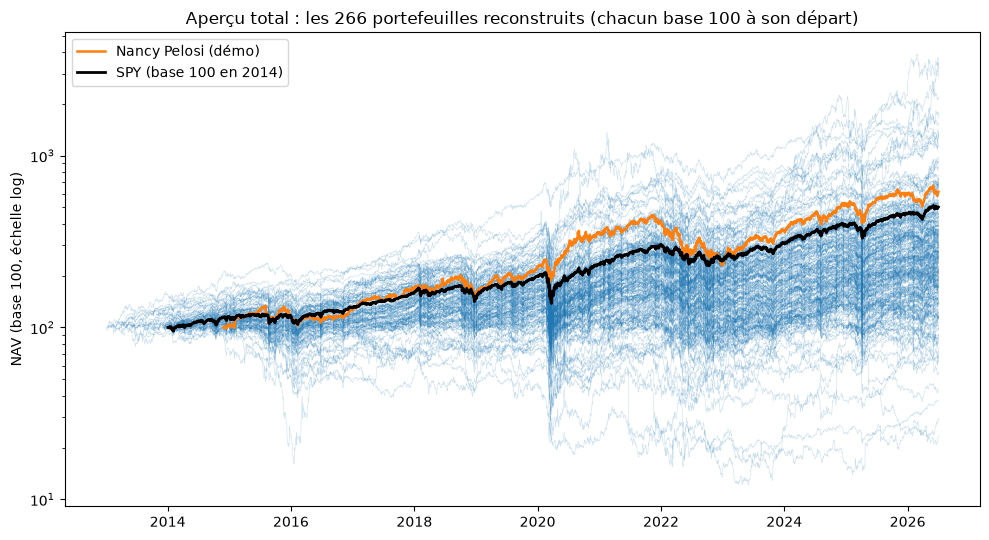

In [7]:
# VISUEL : la NAV de CHAQUE membre (base 100 à son premier jour actif), SPY en noir, démo en orange
plt.figure(figsize=(10, 5.5))
for bid, r in wf_ret.items():
    nav = 100 * (1 + r).cumprod()
    plt.plot(nav.index, nav.values, lw=0.4, alpha=0.22, color="tab:blue")
nav_demo = 100 * (1 + wf_ret[DEMO_BID]).cumprod()
plt.plot(nav_demo.index, nav_demo.values, lw=1.8, color="tab:orange", label=f"{DEMO} (démo)")
cal14 = cal[cal >= "2014-01-01"]
r14 = r_spy.reindex(cal14).fillna(0.0).copy(); r14.iloc[0] = 0.0     # base 100 exactement au 1er jour de 2014
nav_spy = 100 * (1 + r14).cumprod()
plt.plot(nav_spy.index, nav_spy.values, lw=2.0, color="k", label="SPY (base 100 en 2014)")
plt.yscale("log"); plt.ylabel("NAV (base 100, échelle log)")
plt.title(f"Aperçu total : les {len(wf_ret)} portefeuilles reconstruits (chacun base 100 à son départ)")
plt.legend(); plt.tight_layout(); plt.show()

In [8]:
# La distribution des stats sur TOUS les membres (le tableau de la population)
apercu = pd.DataFrame([{**stats(r), "n_days": len(r)} for r in wf_ret.values()])
print(f"la population : quartiles des stats des {len(apercu)} membres reconstruits")
apercu.describe().loc[["mean", "25%", "50%", "75%"]].round(3)

la population : quartiles des stats des 266 membres reconstruits


,cagr,vol,sharpe,maxdd,n_days
mean,0.147,0.254,0.683,-0.398,2078.812
25%,0.090,0.179,0.537,-0.460,1345.750
50%,0.129,0.215,0.709,-0.364,2270.000
75%,0.171,0.282,0.863,-0.310,3039.500


## 3. Qui est éligible ?
Un ratio de performance n'a de sens que sur assez de matière — un IR calculé sur 3 trades explose
(l'écart-type est minuscule) et ne veut rien dire. On ne garde donc que les membres avec :
$$n_{\text{trades}} \ge 10 \quad\text{et}\quad n_{\text{days}} \ge 126\ (\sim 6\ \text{mois}).$$

In [9]:
# Éligibilité PURE (pas encore d'IR) : on part des séries de rendement déjà calculées (wf_ret)
MIN_TRADES, MIN_DAYS = 10, 126
tab = pd.DataFrame([dict(bioguide_id=bid, name=df.loc[df.bioguide_id == bid, "name"].iloc[0],
                         n_trades=len(wf_traded[bid]), n_days=len(r))
                    for bid, r in wf_ret.items()])
elig = tab[(tab.n_trades >= MIN_TRADES) & (tab.n_days >= MIN_DAYS)].copy()
M = len(elig)
print(f"{len(tab)} membres avec historique -> {M} éligibles (>= {MIN_TRADES} trades ET >= {MIN_DAYS} jours)")

266 membres avec historique -> 223 éligibles (>= 10 trades ET >= 126 jours)


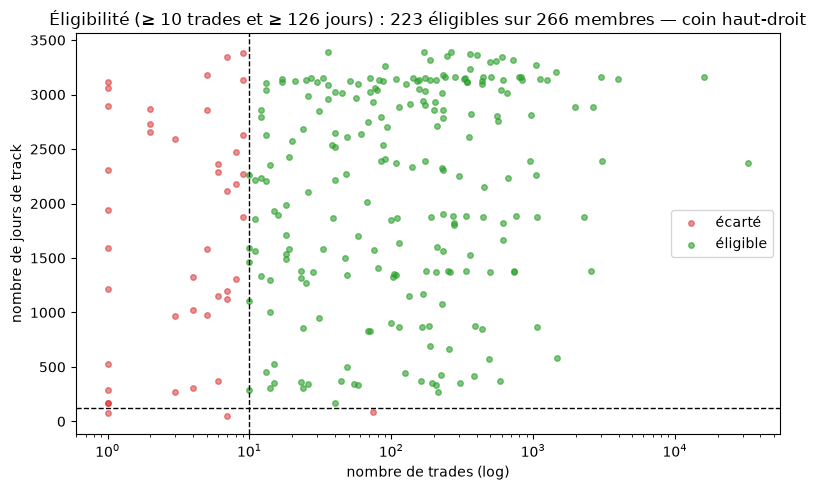

In [10]:
# VISUEL : qui passe la porte ? (n_trades en log x n_jours, la boîte d'éligibilité)
ok = (tab.n_trades >= MIN_TRADES) & (tab.n_days >= MIN_DAYS)
plt.figure(figsize=(8, 5))
plt.scatter(tab.n_trades[~ok], tab.n_days[~ok], s=16, alpha=0.5, color="tab:red", label="écarté")
plt.scatter(tab.n_trades[ok], tab.n_days[ok], s=16, alpha=0.6, color="tab:green", label="éligible")
plt.axvline(MIN_TRADES, color="k", ls="--", lw=1); plt.axhline(MIN_DAYS, color="k", ls="--", lw=1)
plt.xscale("log"); plt.xlabel("nombre de trades (log)"); plt.ylabel("nombre de jours de track")
plt.title(f"Éligibilité (≥ {MIN_TRADES} trades et ≥ {MIN_DAYS} jours) : {M} éligibles sur {len(tab)} membres — coin haut-droit")
plt.legend(); plt.tight_layout(); plt.show()

## 4. Qui bat le SPY — talent ou style ?
Deux critères, testés de la même façon (test $t$ unilatéral, seuil $1{,}645$) :

**Information Ratio** (suppose $\beta=1$) :
$$x(t)=r_P(t)-r_{SPY}(t),\quad \mathrm{IR}=\frac{\overline{x}}{\sigma(x)}\sqrt{252},\quad t=\mathrm{IR}\sqrt{n/252}\quad(n=\text{nb de jours de la série})$$

**Appraisal** (talent, marché retiré) — régression $r_P=\alpha+\beta\,r_{SPY}+\varepsilon$ :
$$\beta=\frac{\mathrm{Cov}(r_P,r_{SPY})}{\mathrm{Var}(r_{SPY})},\ \ \alpha=\overline{r_P}-\beta\,\overline{r_{SPY}},\ \ \text{appraisal}=\frac{\alpha}{\sigma(\varepsilon)}\sqrt{252},\ \ t_{\text{appr}}=\text{appraisal}\sqrt{n/252},\ \ \alpha_{\text{ann}}=(1+\alpha)^{252}-1$$

$\beta=1 \Rightarrow$ appraisal $=$ IR ; sinon l'IR mélange **exposition** (style) et **talent**.
⚠️ Sur $M=223$ tests **corrélés** (mêmes tickers, mêmes périodes), $\sim 11$ dépassements du seuil sont
attendus par pur hasard — et c'est une **borne basse** de l'incertitude (les tests ne sont pas indépendants).

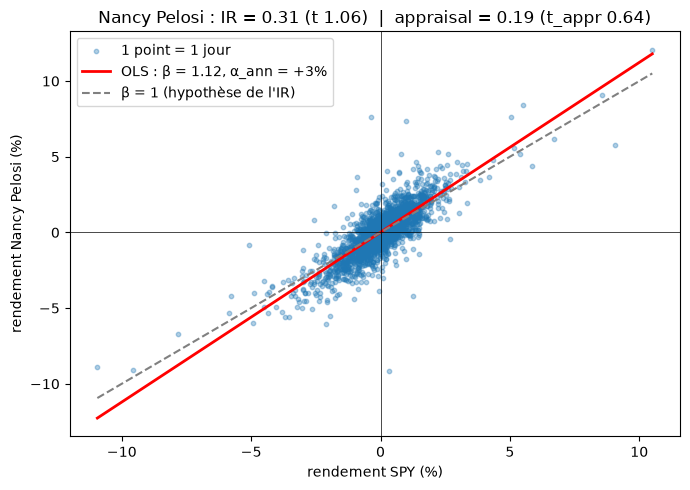

In [11]:
# Illustration AUTO-SUFFISANTE : la régression du membre démo décompose r_P en beta*SPY + alpha (+ résidu)
rm = daily_return(member_shares(df[df["bioguide_id"] == DEMO_BID]))
d = pd.concat([rm.rename("y"), r_spy.reindex(rm.index).rename("x")], axis=1).dropna()
beta, alpha = np.polyfit(d["x"], d["y"], 1)
ab = alpha_beta(rm)
ir = info_ratio(rm); t_ir = ir * np.sqrt(len(rm) / 252)
plt.figure(figsize=(7, 5))
plt.scatter(d["x"] * 100, d["y"] * 100, s=10, alpha=0.35, label="1 point = 1 jour")
xs = np.linspace(d["x"].min(), d["x"].max(), 50)
plt.plot(xs * 100, (alpha + beta * xs) * 100, color="red", lw=2,
         label=f"OLS : β = {beta:.2f}, α_ann = {ab['alpha_ann']:+.0%}")
plt.plot(xs * 100, xs * 100, color="gray", ls="--", label="β = 1 (hypothèse de l'IR)")
plt.axhline(0, color="k", lw=0.5); plt.axvline(0, color="k", lw=0.5)
plt.xlabel("rendement SPY (%)"); plt.ylabel(f"rendement {DEMO} (%)")
plt.title(f"{DEMO} : IR = {ir:.2f} (t {t_ir:.2f})  |  appraisal = {ab['appraisal']:.2f} (t_appr {ab['t_appr']:.2f})")
plt.legend(); plt.tight_layout(); plt.show()

### 4.1 Classement par l'IR
On classe les éligibles par IR et on garde les significatifs ($t>1{,}645$).

In [12]:
elig["IR"] = [info_ratio(wf_ret[b]) for b in elig.bioguide_id]
elig["t"]  = elig.IR * np.sqrt(elig.n_days / 252)
sig = elig[elig.t > 1.645]
print(f"les {len(sig)} membres significatifs par l'IR (t > 1,645) sur {M} éligibles, classés par IR — ~{0.05*M:.0f} attendus par pur hasard")
COLS_IR = ["name", "n_trades", "n_days", "IR", "t"]
sig.sort_values("IR", ascending=False).head(20)[COLS_IR].round(3).reset_index(drop=True)   # tous les significatifs

les 20 membres significatifs par l'IR (t > 1,645) sur 223 éligibles, classés par IR — ~11 attendus par pur hasard


,name,n_trades,n_days,IR,t
0,John Fetterman,10,284,2.482,2.635
1,Ashley Moody,23,364,1.670,2.007
2,Morgan McGarvey,24,853,1.502,2.764
3,Lisa McClain,1479,580,1.264,1.917
4,Daniel S Sullivan,100,904,0.999,1.892
5,Thomas Suozzi,662,2230,0.902,2.683
6,Barbara J Honorable Comstock,85,2390,0.899,2.769
7,MARK R WARNER,15,1934,0.800,2.218
8,David Kustoff,10,1595,0.793,1.994
9,Ron L Wyden,231,1568,0.770,1.920


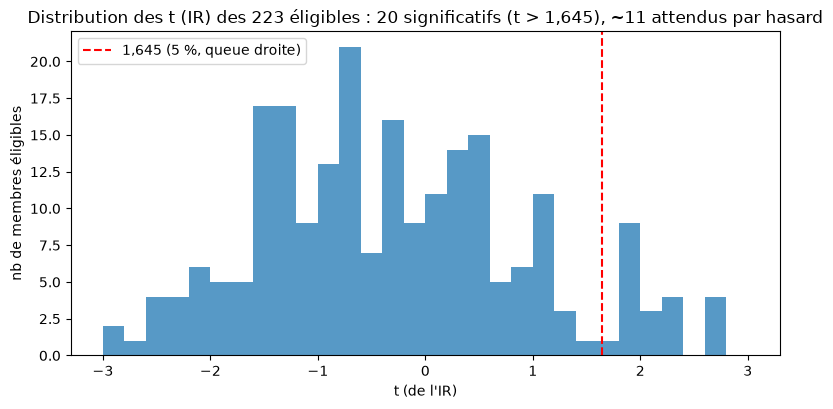

In [13]:
# FIGURE IR (style de référence, copié tel quel en 4.2) : distribution des t
BINS_T = np.linspace(-3, 3, 31)
plt.figure(figsize=(8, 4.2))
plt.hist(elig.t.dropna(), bins=BINS_T, alpha=0.75, color="tab:blue")
plt.axvline(1.645, color="red", ls="--", label="1,645 (5 %, queue droite)")
plt.xlabel("t (de l'IR)"); plt.ylabel("nb de membres éligibles")
plt.title(f"Distribution des t (IR) des {M} éligibles : {len(sig)} significatifs (t > 1,645), ~{0.05*M:.0f} attendus par hasard")
plt.legend(); plt.tight_layout(); plt.show()

### 4.2 Classement par l'appraisal
Exactement la même chose, mais sur le **talent** (β retiré) : on classe par appraisal, on garde $t_{\text{appr}}>1{,}645$.

In [14]:
abdf = pd.DataFrame([alpha_beta(wf_ret[b]) for b in elig.bioguide_id], index=elig.index)
elig = pd.concat([elig, abdf], axis=1)          # ajoute beta / alpha_ann / appraisal / t_appr
sig_appr = elig[elig.t_appr > 1.645]
print(f"les {len(sig_appr)} membres significatifs par l'appraisal (t_appr > 1,645) sur {M} éligibles, classés par appraisal — ~{0.05*M:.0f} attendus par pur hasard")
COLS_APPR = ["name", "n_trades", "n_days", "appraisal", "t_appr"]
sig_appr.sort_values("appraisal", ascending=False).head(12)[COLS_APPR].round(3).reset_index(drop=True)   # tous les significatifs

les 12 membres significatifs par l'appraisal (t_appr > 1,645) sur 223 éligibles, classés par appraisal — ~11 attendus par pur hasard


,name,n_trades,n_days,appraisal,t_appr
0,John Fetterman,10,284,2.242,2.380
1,Morgan McGarvey,24,853,1.081,1.988
2,Raul Ruiz,10,2261,0.802,2.401
3,Trey Hollingsworth,18,1494,0.790,1.924
4,Barbara J Honorable Comstock,85,2390,0.659,2.030
5,MARK R WARNER,15,1934,0.649,1.797
6,Brian Babin,20,2573,0.624,1.995
7,Thomas Suozzi,662,2230,0.589,1.752
8,Pete Sessions,361,3376,0.550,2.013
9,Suzan K. DelBene,158,3054,0.516,1.795


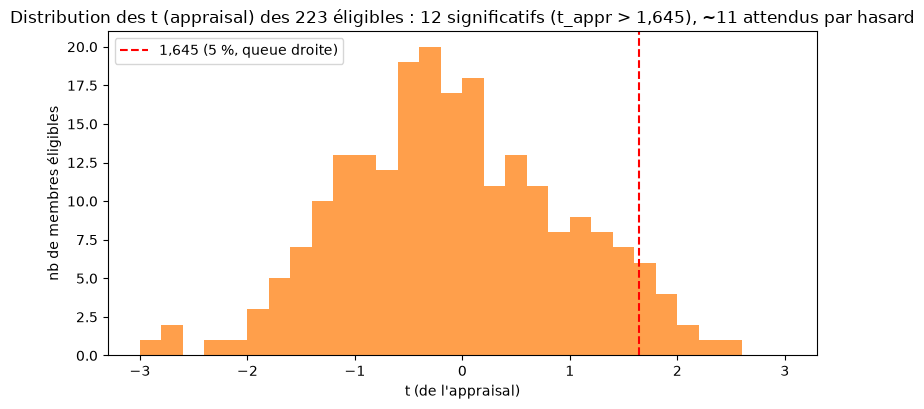

In [15]:
# FIGURE APPRAISAL (copie EXACTE du style de 4.1) : distribution des t_appr
plt.figure(figsize=(8, 4.2))
plt.hist(elig.t_appr.dropna(), bins=BINS_T, alpha=0.75, color="tab:orange")
plt.axvline(1.645, color="red", ls="--", label="1,645 (5 %, queue droite)")
plt.xlabel("t (de l'appraisal)"); plt.ylabel("nb de membres éligibles")
plt.title(f"Distribution des t (appraisal) des {M} éligibles : {len(sig_appr)} significatifs (t_appr > 1,645), ~{0.05*M:.0f} attendus par hasard")
plt.legend(); plt.tight_layout(); plt.show()

### 4.3 Le lien entre les deux
L'IR et l'appraisal ne diffèrent que par le **β**. Chaque point ci-dessous : son IR (vertical) contre
son appraisal (horizontal), coloré par β.

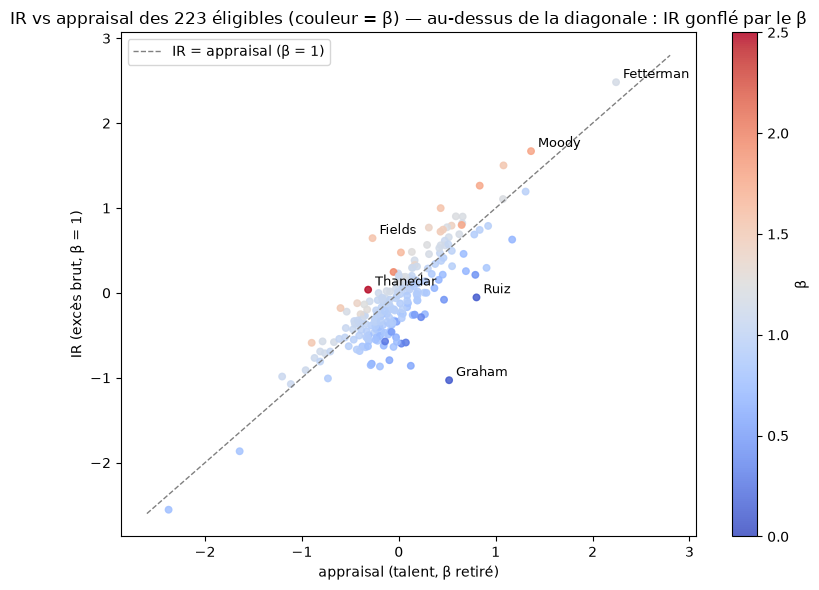

In [16]:
# FIGURE LIEN (le seul endroit où le beta paraît) : IR vs appraisal, couleur = beta
plt.figure(figsize=(8, 6))
sc = plt.scatter(elig.appraisal, elig.IR, c=elig.beta, cmap="coolwarm", vmin=0, vmax=2.5, s=22, alpha=0.85)
plt.colorbar(sc, label="β")
lim = [-2.6, 2.8]
plt.plot(lim, lim, color="gray", ls="--", lw=1, label="IR = appraisal (β = 1)")
for pat in ["Fetterman", "Moody", "Thanedar", "Fields", "Graham", "Ruiz"]:
    m = elig[elig.name.str.contains(pat, na=False)]
    if len(m):
        row = m.iloc[0]
        plt.annotate(pat, (row.appraisal, row.IR), fontsize=9, xytext=(5, 3), textcoords="offset points")
plt.xlabel("appraisal (talent, β retiré)"); plt.ylabel("IR (excès brut, β = 1)")
plt.title(f"IR vs appraisal des {M} éligibles (couleur = β) — au-dessus de la diagonale : IR gonflé par le β")
plt.legend(); plt.tight_layout(); plt.show()

## 5. Choisir qui copier chaque année (walk-forward, point-in-time)
À chaque fin d'année $Y$, on classe les éligibles *à la coupe* (seuils du §3 recalculés sur les données $\le 31/12/Y$)
par un **critère** et on garde les significatifs :
$$\mathrm{classement}(Y)=\{\text{éligibles}\ \wedge\ t_{\text{crit}}>1{,}645\}\ \text{triés par le critère},$$
top-$K$ suivi en $Y{+}1$ (s'il y a moins de $K$ significatifs, on copie tous les significatifs). Aucun regard vers le futur : $n_i(t)$ ne dépend que des trades $\le t$.
Même mécanique pour les **deux** critères (IR, appraisal) ; le choix du critère est étudié en §6.

⚠ Nuance (auditée) : la coupe tronque la série *pré-calculée* (`r.loc[:31/12/Y]`), dont la **fin de fenêtre**
(§2 : dernier jour actif) est connue *ex post* — un membre revenu à zéro position avant la coupe mais qui
re-trade après garde ses jours plats jusqu'à la coupe. Vérifié exhaustivement : 2 couples membre×coupe
concernés (Rouda 2019, Spartz 2024), aucun significatif, **aucun classement modifié** à aucune coupe.

In [17]:
def classement_a_fin(Y, min_trades=MIN_TRADES, min_days=MIN_DAYS, seuil_t=1.645, critere="ir"):
    """Classement point-in-time au 31/12/Y. critere = "ir" (excès/SPY) ou "appraisal" (régression β)."""
    yend = pd.Timestamp(f"{Y}-12-31")
    rows = []
    for bid, r in wf_ret.items():
        rr = r.loc[:yend]
        n_trades = int((wf_traded[bid] <= yend).sum())
        n_days = len(rr)
        if n_days < 2 or rr.std() == 0 or n_trades < min_trades or n_days < min_days:
            continue
        if critere == "ir":
            x = (rr - r_spy.reindex(rr.index)).dropna()
            if len(x) < 2 or x.std() == 0:
                continue
            score = x.mean() / x.std() * np.sqrt(252)
            t = score * np.sqrt(n_days / 252)
        else:                                            # appraisal : régression sur le seul passé <= Y
            ab = alpha_beta(rr)
            score, t = ab["appraisal"], ab["t_appr"]
            if not np.isfinite(t):
                continue
        if t <= seuil_t:
            continue
        rows.append(dict(bioguide_id=bid, name=df.loc[df.bioguide_id == bid, "name"].iloc[0],
                         n_trades=n_trades, n_days=n_days, score=score, t=t))
    cols = ["bioguide_id", "name", "n_trades", "n_days", "score", "t"]
    return (pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
            if rows else pd.DataFrame(columns=cols))

# Les DEUX caches co-définis ici (jamais de sélection avant que son cache existe)
clsmt    = {Y: classement_a_fin(Y, critere="ir")        for Y in range(2014, 2027)}
clsmt_ap = {Y: classement_a_fin(Y, critere="appraisal") for Y in range(2014, 2027)}

def select_topK(Y, K, critere="ir"):
    cache = clsmt if critere == "ir" else clsmt_ap
    c = cache[Y] if Y in cache else classement_a_fin(Y, critere=critere)
    return list(zip(c["score"].head(K), c["bioguide_id"].head(K)))
print("classements point-in-time prêts (IR et appraisal, 2014-2026)")

classements point-in-time prêts (IR et appraisal, 2014-2026)


In [18]:
# TABLE SYMÉTRIQUE : nb de significatifs et tête du classement, par critère, à chaque coupe
def _tete(c): return c["name"].iloc[0].split()[-1] if len(c) else "-"
resume = pd.DataFrame([
    dict(fenetre=f"≤ {Y}", n_sig_IR=len(clsmt[Y]), n_sig_appr=len(clsmt_ap[Y]),
         tete_IR=_tete(clsmt[Y]), tete_appr=_tete(clsmt_ap[Y]))
    for Y in range(2014, 2027)])
print(f"les {len(resume)} coupes annuelles 2014-2026 : nb de significatifs et tête du classement, par critère")
resume

les 13 coupes annuelles 2014-2026 : nb de significatifs et tête du classement, par critère


,fenetre,n_sig_IR,n_sig_appr,tete_IR,tete_appr
0,≤ 2014,1,3,Reed,Reed
1,≤ 2015,4,4,McKinley,Chabot
2,≤ 2016,2,4,Long,Brooks
3,≤ 2017,4,4,Comstock,Khanna
4,≤ 2018,5,7,Heck,Heck
5,≤ 2019,8,11,Evans,Lee
6,≤ 2020,19,21,Beyer,Beyer
7,≤ 2021,13,10,Comstock,Heck
8,≤ 2022,7,7,DelBene,Coble
9,≤ 2023,12,12,Landsman,Sullivan


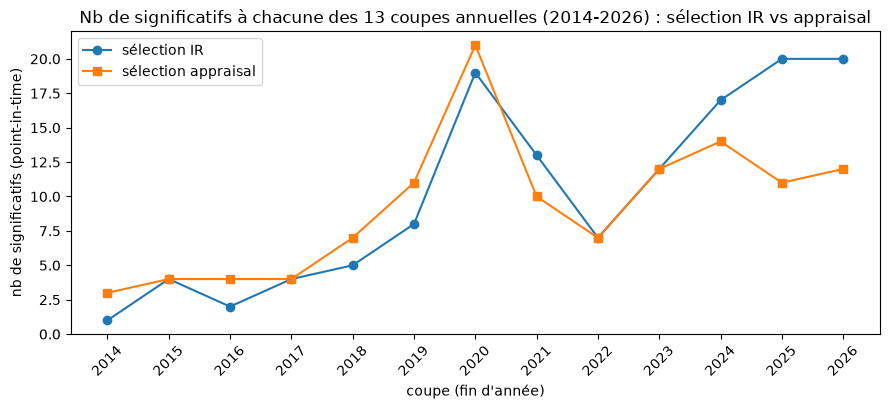

In [19]:
# FIGURE SYMÉTRIQUE : nb de significatifs par an, IR vs appraisal
annees = list(range(2014, 2027))
plt.figure(figsize=(9, 4.2))
plt.plot(annees, [len(clsmt[Y]) for Y in annees], marker="o", label="sélection IR")
plt.plot(annees, [len(clsmt_ap[Y]) for Y in annees], marker="s", label="sélection appraisal")
plt.xticks(annees, [str(y) for y in annees], rotation=45)
plt.ylabel("nb de significatifs (point-in-time)"); plt.xlabel("coupe (fin d'année)")
plt.title(f"Nb de significatifs à chacune des {len(annees)} coupes annuelles (2014-2026) : sélection IR vs appraisal")
plt.legend(); plt.tight_layout(); plt.show()

## 6. Le portefeuille de copy-trading top-$K$ (sélection IR ∥ appraisal) : bat-il le SPY ?
Chaque fin d'année, on copie les $K$ premiers membres du classement point-in-time (§5) — classés
par IR, ou par appraisal — et on tient le panier un an. Ici $K=4$ ; le choix de $K$ est étudié
au §7. Construction standard des fonds : méthode **unitisée** (parts et NAV), **buy-and-hold**
entre deux rebalancements.

### 6.1 La construction en parts
**Ingrédients.** Coupes de rebalancement $t^R_Y$ = dernier jour coté de l'année $Y$
($Y=2015,\dots,2025$) ; sélection $\mathcal{S}_Y$ = top-$K$ du classement point-in-time à la
coupe (§5) ; poids cibles égaux $w_k=\frac{1}{|\mathcal{S}_Y|}$ avec $|\mathcal{S}_Y|=\min(K,\ \text{nb de
significatifs à la coupe})$, $\sum_k w_k=1$ ; richesse initiale
$W(t^R_{2015})=100$.

**Chaque membre $k$ = un fonds**, dont le prix de part est sa NAV (rendement $r_k$ du §2) :
$$\mathrm{NAV}^k(t)=\prod_{s\le t}\big(1+r_k(s)\big)$$

**L'état du portefeuille = ses nombres de parts** $\mathrm{nbr}^k_Y$. À chaque coupe $t^R_Y$,
en fin de journée : (i) on **compte** la richesse disponible avec les anciennes parts, aux prix
du jour ; (ii) on la **redéploie** selon les poids cibles :
$$\text{(i)}\quad W(t^R_Y)=\!\!\sum_{k\in\mathcal{S}_{Y-1}}\!\!\mathrm{nbr}^k_{Y-1}\,\mathrm{NAV}^k(t^R_Y)
\qquad\qquad
\text{(ii)}\quad \mathrm{nbr}^k_Y=\frac{w_k\,W(t^R_Y)}{\mathrm{NAV}^k(t^R_Y)},\quad k\in\mathcal{S}_Y$$

**Entre deux coupes** ($t^R_Y<t\le t^R_{Y+1}$), les parts ne bougent pas — c'est le buy-and-hold
($\mathrm{NAV}$ sans exposant = le panier ; $\mathrm{NAV}^k$ = la NAV du §2 du membre $k$) :
$$\mathrm{NAV}(t)=\!\!\sum_{k\in\mathcal{S}_Y}\!\!\mathrm{nbr}^k_Y\,\mathrm{NAV}^k(t)
\qquad\Longrightarrow\qquad
\boxed{\;r_{\text{strat}}(t)=\frac{\mathrm{NAV}(t)}{\mathrm{NAV}(t-1)}-1\;}$$

**Deux propriétés.**
- **Autofinancement** : $\sum_{k\in\mathcal{S}_Y}\mathrm{nbr}^k_Y\,\mathrm{NAV}^k(t^R_Y)=W(t^R_Y)$
  (car $\sum_k w_k=1$) $\Rightarrow$ la NAV est **continue** à chaque coupe — aucun apport, aucun
  retrait, on ne fait que réallouer.
- **Poids effectifs dérivants** : $w_k(t)=\dfrac{\mathrm{nbr}^k_Y\,\mathrm{NAV}^k(t)}{\mathrm{NAV}(t)}
  \ne w_k$ dès le lendemain de la coupe. Les figer — $r_{\text{strat}}(t)=\sum_k w_k\,r_k(t)$ —
  reviendrait à rebalancer chaque jour (une stratégie *constant-mix*, pas du copier-et-tenir).

In [20]:
# Le prix de part de chaque membre-fonds, calculé UNE FOIS sur tout le calendrier
NAVK = pd.DataFrame({bid: (1 + r.reindex(cal).fillna(0.0)).cumprod() for bid, r in wf_ret.items()})

def _parts_engine(blocs, W0=100.0):
    """blocs = [(jours tenus, bids, poids initiaux)] chronologiques -> dict r / nav / journal."""
    W, rets, navs, journal = W0, [], [], []
    for idx, bids, w in blocs:
        tR = cal[cal.get_loc(idx[0]) - 1]                  # coupe = veille du 1er jour tenu (fin de journée)
        nbr = pd.Series(w * W / NAVK.loc[tR, bids].values, index=bids)   # nbr^k = w_k·W / NAV^k(tR)
        nav = NAVK.loc[idx, bids].mul(nbr, axis=1).sum(axis=1)           # NAV(t) = Σ nbr^k·NAV^k(t)
        r = nav / nav.shift(1) - 1
        r.iloc[0] = nav.iloc[0] / W - 1                    # 1er jour : contre la richesse redéployée
        journal.append(dict(rebal=tR, nbr=nbr, W_avant=W, W_apres=float(nav.iloc[-1])))
        W = float(nav.iloc[-1])                            # autofinancement -> coupe suivante
        rets.append(r); navs.append(nav)
    return dict(r=pd.concat(rets).sort_index(), nav=pd.concat(navs).sort_index(), journal=journal)

def _poids(sel, mode):
    if mode == "equal":
        return np.ones(len(sel)) / len(sel)
    sc = np.array([s for s, _ in sel])
    return sc / sc.sum() if sc.sum() > 0 else np.ones(len(sel)) / len(sel)

def strategie_en_parts(K, mode="equal", critere="ir", cadence="annuel"):
    """Sélections annuelles (§5) ou semestrielles ("6m" : requiert clsmt6_*/cuts/next_bound du §8), combinées en PARTS."""
    blocs = []
    if cadence == "annuel":
        for Y in range(2015, 2026):
            sel = select_topK(Y, K, critere=critere)
            idx = cal[cal.year == (Y + 1)]
            if sel and len(idx):
                blocs.append((idx, [b for _, b in sel], _poids(sel, mode)))
    else:                                                  # "6m" : coupes 30/06 & 31/12 du §8
        cache = clsmt6_ir if critere == "ir" else clsmt6_ap
        for d in cuts:
            c = cache[d]
            if len(c) == 0:
                continue
            sel = list(zip(c["score"].head(K), c["bioguide_id"].head(K)))
            idx = cal[(cal > d) & (cal <= next_bound(d))]
            if len(idx):
                blocs.append((idx, [b for _, b in sel], _poids(sel, mode)))
    return _parts_engine(blocs)

print(f"moteur en parts prêt | {NAVK.shape[1]} fonds-membres")

moteur en parts prêt | 266 fonds-membres


### 6.2 L'évaluation
**Excès par année civile** (1 année = 1 observation) :
$$x_Y=\prod_{t\in Y}\big(1+r_{\text{strat}}(t)\big)-\prod_{t\in Y}\big(1+r_{\text{SPY}}(t)\big),\qquad
\mathrm{IR}_{\text{ann}}=\frac{\overline{x}}{\sigma(x)},\qquad t=\mathrm{IR}_{\text{ann}}\sqrt{n}$$
Seuil unilatéral 5 % : $t_{10}\approx 1{,}81$ pour $n=11$ années (2026, partielle — données
jusqu'au 02/07/2026 — compte pour une observation).

**Même test qu'au §4** : $x$ = excès par période (jour au §4, année civile ici, semestre au §8),
$t=\overline{x}\big/\big(\sigma(x)/\sqrt{n}\big)$ avec $n$ = nombre de périodes — l'IR n'est que ce $t$
remis à l'échelle ($\mathrm{IR}=\sqrt{252}\,\overline{x}/\sigma$ en quotidien ;
$\mathrm{IR}_{\text{ann}}$, $\mathrm{IR}_{\text{sem}}=\overline{x}/\sigma$ par période).

**Ajustement au marché** — la régression du §4, appliquée à la série de la stratégie :
$$r_{\text{strat}}(t)=\alpha+\beta\,r_{\text{SPY}}(t)+\varepsilon(t),\qquad
\alpha_{\text{ann}}=(1+\alpha)^{252}-1$$
Si $\beta>1$, une part de l'excès brut n'est que de l'exposition au marché : $\alpha<$ excès brut.

In [21]:
# Évaluation par années civiles (1 année = 1 observation) + LA série de référence, calculée UNE fois
def yearly_excess(r):
    b = r_spy.reindex(r.index).fillna(0.0)
    return pd.Series({y: ((1 + r[r.index.year == y]).prod() - 1) - ((1 + b[r.index.year == y]).prod() - 1)
                      for y in sorted(set(r.index.year))})

def eval_yearly(r):
    e = yearly_excess(r); n = len(e); ir_an = e.mean() / e.std(ddof=1)
    return dict(exces_moyen=e.mean(), IR_annuel=ir_an, t=ir_an * np.sqrt(n), gagnantes=f"{int((e > 0).sum())}/{n}")

def _ligne(r):
    e = eval_yearly(r); a = alpha_beta(r)
    return dict(exces_an=e["exces_moyen"], t=e["t"], gagnantes=e["gagnantes"],
                beta=a["beta"], alpha_ann=a["alpha_ann"], t_appr=a["t_appr"])

det4    = strategie_en_parts(4, "equal", "ir")   # dict r / nav / journal — réutilisé par le zoom et la figure
r_dr_eq = det4["r"]
r_ap_eq = strategie_en_parts(4, "equal", "appraisal")["r"]   # 2e série de référence, réutilisée aux §7-§8
print(f"évaluation annuelle prête | séries top-4 (sélection IR et appraisal) : {len(yearly_excess(r_dr_eq))} années de tenue (2016-2026)")

évaluation annuelle prête | séries top-4 (sélection IR et appraisal) : 11 années de tenue (2016-2026)


### 6.3 Le résultat top-4
Cas de référence : $K=4$, poids égaux, rebalancement annuel (2016-2026), deux critères de sélection
(IR, appraisal). Tenue 2017, sélection IR : 2 significatifs seulement à la coupe (table du §5)
$\Rightarrow$ poids $1/2$ cette année-là, $1/4$ partout ailleurs.

**Comment lire la table.** Deux blocs de colonnes, deux mesures différentes :
- **excès/an, t, gagnantes** — sur les 11 **excès annuels** $x_Y=\prod_{t\in Y}(1+r_{\text{strat}})-\prod_{t\in Y}(1+r_{\text{SPY}})$ (§6.2), qui supposent $\beta=1$ (excès **brut** vs SPY) :
  - **excès/an** $=\overline{x}$, la moyenne des 11 ;
  - **t** $=\dfrac{\overline{x}}{\sigma(x)}\sqrt{11}$, seuil $1{,}81$ ;
  - **gagnantes** $=$ nombre d'années où $x_Y>0$ (sur 11) ; les autres sont **perdantes** (ex. $7/11 \Rightarrow$ 7 gagnantes, 4 perdantes).
- **β, α annualisé, t (appraisal)** — de la régression **quotidienne** $r_{\text{strat}}=\alpha+\beta\,r_{\text{SPY}}+\varepsilon$ (§4), qui **retire le β** ; $\alpha_{\text{ann}}=(1+\alpha)^{252}-1$.

⚠️ Les deux blocs ne disent pas la même chose : l'excès brut $+3{,}1\,\%$ (sél IR) devient $\alpha\approx 0$ une fois le $\beta=1{,}20$ retiré — c'était du **style de marché**, pas du talent.

In [22]:
# LES MÉTRIQUES du top-4, par critère de sélection (mêmes colonnes que les tables des §7-§8)
print(f"top-4 (poids 1/4, rebalancement annuel) — {len(yearly_excess(r_dr_eq))} années civiles, seuil t₁₀ ≈ 1,81")
pd.DataFrame({
    "sélection IR":        _ligne(r_dr_eq),
    "sélection appraisal": _ligne(r_ap_eq),
}).T.round(3)

top-4 (poids 1/4, rebalancement annuel) — 11 années civiles, seuil t₁₀ ≈ 1,81


,exces_an,t,gagnantes,beta,alpha_ann,t_appr
sélection IR,0.027909,0.797518,7/11,1.211435,-0.010845,-0.310296
sélection appraisal,-0.025324,-1.246978,3/11,1.009594,-0.02295,-0.757885


⚠️ **Rétrospectif vs temps réel.** Les classements du §4 sont calculés sur **tout** l'historique
(photo après coup) ; ici la sélection n'utilise que le **passé disponible** à chaque coupe, et on
mesure l'année **suivante**. Un excès négatif ici, alors que les appraisals du §4.2 sont positifs,
signifie simplement que le talent passé ne se **répète pas** l'année d'après.

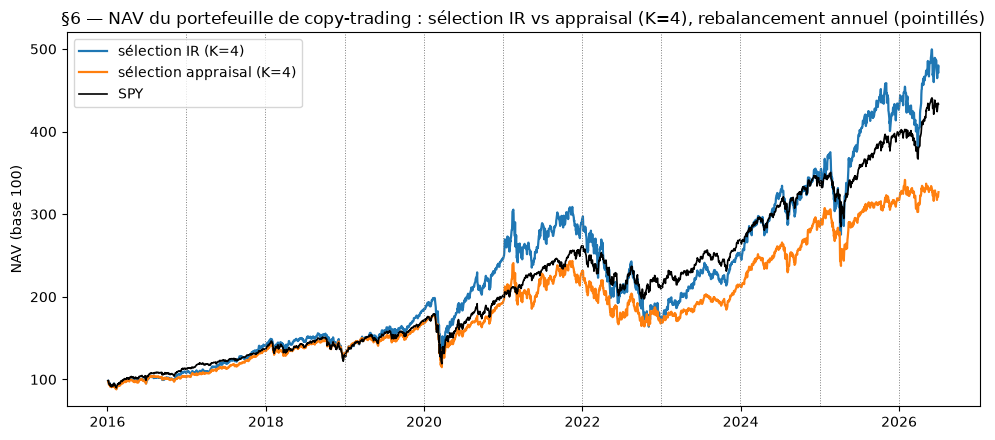

In [23]:
# FIGURE : NAV du portefeuille de copy-trading (base 100) — sélection IR vs appraisal (K=4)
nav_ir = 100 * (1 + r_dr_eq).cumprod()
nav_ap = 100 * (1 + r_ap_eq).cumprod()
nav_sp = 100 * (1 + r_spy.reindex(nav_ir.index).fillna(0)).cumprod()
plt.figure(figsize=(10, 4.5))
plt.plot(nav_ir, label="sélection IR (K=4)", lw=1.6)
plt.plot(nav_ap, label="sélection appraisal (K=4)", lw=1.6)
plt.plot(nav_sp, label="SPY", color="k", lw=1.2)
for j in det4["journal"][1:]:
    plt.axvline(j["rebal"], color="gray", ls=":", lw=0.7)          # rebalancements : la NAV en parts reste continue
plt.ylabel("NAV (base 100)")
plt.title("§6 — NAV du portefeuille de copy-trading : sélection IR vs appraisal (K=4), rebalancement annuel (pointillés)")
plt.legend(); plt.tight_layout(); plt.show()

### Carte des expériences (§7–§10)

$$\star\;=\;\big(\text{sélection IR}\,\|\,\text{appraisal},\ \ K=4\ \text{fixe},\ \ \text{rebalancement annuel},\ \ w=1/K,\ \ \Sigma=\hat\Sigma^{\text{emp}}\big)\qquad(=\ \text{la ligne du §6.3}).$$

| § | axe qu'il fait varier | valeurs testées | le reste |
|---|---|---|---|
| §7 | $K$ (nb de membres copiés) | $4$ fixe vs walk-forward $\in[4,20]$ | $=\star$ |
| §8 | cadence | annuel vs 6 mois | rejoue les 4 stratégies du §7 |
| §9 | poids $w$ | $1/K$, inverse-vol, ERC, GMV | $K=4$ fixe ; annuel **et** 6 mois |
| §10 | estimateur de $\Sigma$ | cov brute vs Ledoit-Wolf (3 cibles) | $K=4$ fixe ; ERC/GMV ; annuel **et** 6 mois |

- **Un axe à la fois, jamais combinés** (pas de $K$ walk-forward × inverse-vol) : chaque table se lit contre la même baseline $\star$, répétée en 1re ligne.
- ⚠ Le symbole $K$ : **nombre** de membres copiés (l'axe du §7) $\neq$ « $1/K$ » $=$ nom du schéma de **poids égaux** (l'axe du §9). Deux choses différentes.

## 7. Combien copier ? (le choix de $K$)
On construit les stratégies pour tout $K\in[4,20]$, puis on choisit $K$ **honnêtement** (sans regard
futur), avec **le critère de la sélection lui-même** :
$$K^*(Y)=\arg\max_K \;\mathrm{score}_{\text{crit}}\big(\text{strat-}K\big|_{\le Y}\big),\quad
\mathrm{score}_{\text{crit}}=\begin{cases}\mathrm{IR}_{\text{quotidien}}&\text{sélection IR}\\
\text{appraisal}_{\text{quotidien}}&\text{sélection appraisal}\end{cases}$$
$K=4$ par défaut sans historique ; à égalité de score (fréquent quand $n_{\text{sig}}<K$ : les
stratégies coïncident), on prend le plus petit $K$. Le **tableau** ci-dessous donne le $K$ appliqué **chaque année de tenue** (choisi à la coupe de fin d'année précédente) et l'excès
réalisé cette année-là ; puis on compare **$K=4$ fixe** à
**$K$ walk-forward**, pour les deux sélections.

In [24]:
# Précalcul des séries-K, PAR CRITÈRE DE SÉLECTION (poids 1/K fixé)
KS = list(range(4, 21))
R_K_ir = {K: strategie_en_parts(K, "equal", "ir")["r"]        for K in KS}
R_K_ap = {K: strategie_en_parts(K, "equal", "appraisal")["r"] for K in KS}
print(f"{2*len(KS)} séries-K prêtes (sélection IR et appraisal)")

34 séries-K prêtes (sélection IR et appraisal)


In [25]:
# K walk-forward : chaque critère choisit K avec SON PROPRE mètre (IR ou appraisal quotidien)
def score_ir(r):
    x = (r - r_spy.reindex(r.index)).dropna()
    return x.mean() / x.std() * np.sqrt(252) if x.std() > 0 else -np.inf

def score_appr(r):
    a = alpha_beta(r)["appraisal"]           # appraisal = alpha risque-ajusté de la stratégie vs SPY
    return a if np.isfinite(a) else -np.inf

def k_walk_forward(RbyK, score):
    parts, rows = [], []
    for Y in range(2015, 2026):
        if Y == 2015:
            k_star = 4                                    # aucun historique
        else:
            fin = pd.Timestamp(f"{Y}-12-31")
            sc = {K: score(RbyK[K].loc[:fin]) for K in KS}
            best = max(sc.values()); k_star = min(K for K in KS if sc[K] == best)
        ry = RbyK[k_star][RbyK[k_star].index.year == Y + 1]
        parts.append(ry)
        b = r_spy.reindex(ry.index).fillna(0.0)
        rows.append(dict(annee_tenue=Y + 1, K_choisi=k_star,
                         exces_realise=((1 + ry).prod() - 1) - ((1 + b).prod() - 1)))
    return pd.concat(parts).sort_index(), pd.DataFrame(rows)

r_wfK_eq, chemin_ir = k_walk_forward(R_K_ir, score_ir)     # sélection IR  -> K par IR
r_wfK_ap, chemin_ap = k_walk_forward(R_K_ap, score_appr)   # sélection appr -> K par appraisal
print("walk-forward K prêt (IR par IR, appraisal par appraisal)")

walk-forward K prêt (IR par IR, appraisal par appraisal)


In [26]:
# TABLEAU : le K retenu CHAQUE ANNÉE par le walk-forward (il change d'une année à l'autre)
pct = lambda x: f"{x:+.1%}".replace("-", "−").replace(".", ",")
tabK = pd.DataFrame({
    "K (sél IR)":           chemin_ir.set_index("annee_tenue")["K_choisi"],
    "excès réalisé (IR)":   chemin_ir.set_index("annee_tenue")["exces_realise"].map(pct),
    "K (sél appraisal)":    chemin_ap.set_index("annee_tenue")["K_choisi"],
    "excès réalisé (appr)": chemin_ap.set_index("annee_tenue")["exces_realise"].map(pct),
})
tabK.index.name = "année tenue"
print(f"le K retenu chaque année par le walk-forward (K ∈ [{KS[0]}, {KS[-1]}]) et l'excès réalisé cette année-là — {len(tabK)} années de tenue")
tabK

le K retenu chaque année par le walk-forward (K ∈ [4, 20]) et l'excès réalisé cette année-là — 11 années de tenue


,K (sél IR),excès réalisé (IR),K (sél appraisal),excès réalisé (appr)
année tenue,,,,
2016,4,"−4,2%",4,"−9,6%"
2017,4,"+8,5%",4,"+9,7%"
2018,4,"−1,4%",4,"+2,8%"
2019,4,"+7,6%",4,"−4,4%"
2020,4,"+15,9%",7,"+1,6%"
2021,8,"−6,1%",11,"−9,8%"
2022,18,"−9,9%",20,"−3,7%"
2023,12,"+12,1%",20,"+6,2%"
2024,18,"+4,4%",20,"+1,0%"


In [27]:
# Comparaison : K = 4 fixe vs K walk-forward, pour chaque critère de sélection
print(f"K=4 fixe vs K walk-forward, par critère de sélection — {len(yearly_excess(r_dr_eq))} années, seuil t₁₀ ≈ 1,81")
pd.DataFrame({
    "K=4 fixe (sél IR)":              _ligne(r_dr_eq),
    "K walk-forward (sél IR)":        _ligne(r_wfK_eq),
    "K=4 fixe (sél appraisal)":       _ligne(r_ap_eq),
    "K walk-forward (sél appraisal)": _ligne(r_wfK_ap),
}).T.round(3)

K=4 fixe vs K walk-forward, par critère de sélection — 11 années, seuil t₁₀ ≈ 1,81


,exces_an,t,gagnantes,beta,alpha_ann,t_appr
K=4 fixe (sél IR),0.027909,0.797518,7/11,1.211435,-0.010845,-0.310296
K walk-forward (sél IR),0.04059,1.580932,7/11,1.168338,0.011438,0.443818
K=4 fixe (sél appraisal),-0.025324,-1.246978,3/11,1.009594,-0.02295,-0.757885
K walk-forward (sél appraisal),-0.010029,-0.546117,5/11,0.97328,-0.005835,-0.292165


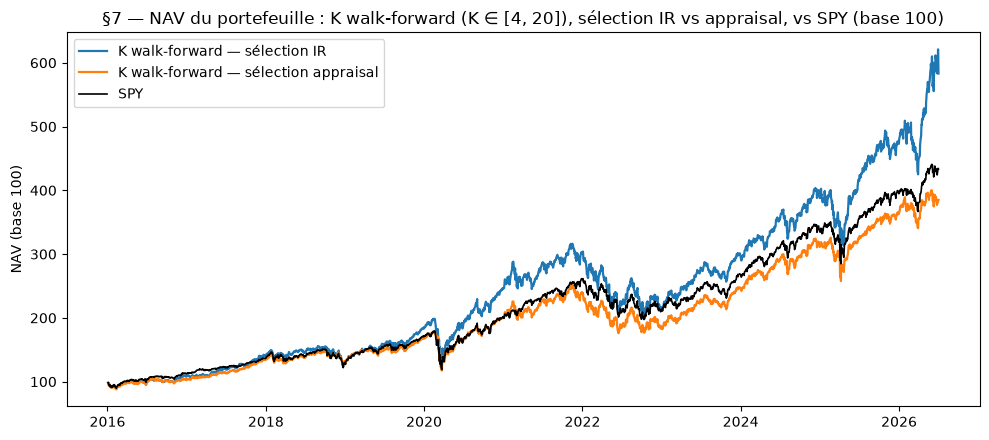

In [28]:
# FIGURE : NAV du portefeuille — K choisi en WALK-FORWARD (sélection IR vs appraisal) vs SPY (base 100)
nav_wf_ir = 100 * (1 + r_wfK_eq).cumprod()
nav_wf_ap = 100 * (1 + r_wfK_ap).cumprod()
idx = nav_wf_ir.index.union(nav_wf_ap.index)
nav_wf_sp = 100 * (1 + r_spy.reindex(idx).fillna(0)).cumprod()
plt.figure(figsize=(10, 4.5))
plt.plot(nav_wf_ir, label="K walk-forward — sélection IR", lw=1.6)
plt.plot(nav_wf_ap, label="K walk-forward — sélection appraisal", lw=1.6)
plt.plot(nav_wf_sp, label="SPY", color="k", lw=1.2)
plt.ylabel("NAV (base 100)")
plt.title(f"§7 — NAV du portefeuille : K walk-forward (K ∈ [{KS[0]}, {KS[-1]}]), sélection IR vs appraisal, vs SPY (base 100)")
plt.legend(); plt.tight_layout(); plt.show()

## 8. Et si on rééquilibre tous les 6 mois ?
Même logique qu'aux §5-§7, mais on **re-sélectionne 2× par an** : coupe au **30/06** et au **31/12**, on
tient le **semestre suivant**. Rien ne change au portefeuille des membres — seule la **cadence** de
sélection/tenue change, et l'évaluation passe à l'**excès par semestre** :
$$\mathrm{IR}_{\text{sem}}=\frac{\overline{x_{\text{sem}}}}{\sigma(x_{\text{sem}})},\qquad
t=\mathrm{IR}_{\text{sem}}\sqrt{n},\quad n\approx 22\ \text{semestres (au lieu de 11 ans)}.$$
Le seuil de significativité (unilatéral 5 %) passe donc à **$t>1{,}72$** (au lieu de 1,81).
Dans la table, excès/an $=2\,\overline{x}_{\text{sem}}$ (annualisation arithmétique, pour comparer
au §7 ; $t$ et gagnantes restent calculés sur les semestres). Le semestriel commence un semestre
plus tôt (S2-2015, première coupe au 30/06/2015) que l'annuel (2016) — d'où $n=22$. On rejoue les
**mêmes 4 stratégies qu'au §7** (K=4 et K walk-forward, sélection IR ∥ appraisal), mais à 6 mois —
à comparer ligne à ligne au tableau annuel du §7.

In [29]:
# --- Coupes SEMESTRIELLES : 30/06 & 31/12, classements point-in-time ; combinaison = moteur en parts du §6 ---
def classement_a_date(d, min_trades=MIN_TRADES, min_days=MIN_DAYS, seuil_t=1.645, critere="ir"):
    """classement_a_fin, mais à une DATE de coupe quelconque (point-in-time strict <= d)."""
    rows = []
    for bid, r in wf_ret.items():
        rr = r.loc[:d]
        n_trades = int((wf_traded[bid] <= d).sum()); n_days = len(rr)
        if n_days < 2 or rr.std() == 0 or n_trades < min_trades or n_days < min_days:
            continue
        if critere == "ir":
            x = (rr - r_spy.reindex(rr.index)).dropna()
            if len(x) < 2 or x.std() == 0:
                continue
            score = x.mean() / x.std() * np.sqrt(252); t = score * np.sqrt(n_days / 252)
        else:
            ab = alpha_beta(rr); score, t = ab["appraisal"], ab["t_appr"]
            if not np.isfinite(t):
                continue
        if t <= seuil_t:
            continue
        rows.append(dict(bioguide_id=bid, score=score))
    return (pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
            if rows else pd.DataFrame(columns=["bioguide_id", "score"]))

cuts = [pd.Timestamp(y, m, dd) for y in range(2015, 2026) for (m, dd) in [(6, 30), (12, 31)]]
next_bound = lambda d: pd.Timestamp(d.year, 12, 31) if d.month == 6 else pd.Timestamp(d.year + 1, 6, 30)
clsmt6_ir = {d: classement_a_date(d, critere="ir")        for d in cuts}
clsmt6_ap = {d: classement_a_date(d, critere="appraisal") for d in cuts}

def eval_sem(r):
    b = r_spy.reindex(r.index).fillna(0.0)
    sem = r.index.year.values * 2 + (r.index.month.values > 6).astype(int)
    e = pd.Series({s: ((1 + r[sem == s]).prod() - 1) - ((1 + b[sem == s]).prod() - 1) for s in sorted(set(sem))})
    n = len(e); ir = e.mean() / e.std(ddof=1)
    return dict(exces_an=2 * e.mean(), t=ir * np.sqrt(n), gagnantes=f"{int((e > 0).sum())}/{n}", n=n)

def _ligne6(r):
    e = eval_sem(r); a = alpha_beta(r)
    return dict(exces_an=e["exces_an"], t=e["t"], gagnantes=e["gagnantes"],
                beta=a["beta"], alpha_ann=a["alpha_ann"], t_appr=a["t_appr"])

r_6m_ir = strategie_en_parts(4, "equal", "ir",        "6m")["r"]
r_6m_ap = strategie_en_parts(4, "equal", "appraisal", "6m")["r"]
print(f"coupes semestrielles prêtes | {len(cuts)} coupes | n semestres : IR={eval_sem(r_6m_ir)['n']}, appr={eval_sem(r_6m_ap)['n']}")

coupes semestrielles prêtes | 22 coupes | n semestres : IR=22, appr=22


In [30]:
# CHOIX DE K à 6 mois : séries-K semestrielles + K walk-forward (critère apparié comme §7)
R_K6_ir = {K: strategie_en_parts(K, "equal", "ir",        "6m")["r"] for K in KS}
R_K6_ap = {K: strategie_en_parts(K, "equal", "appraisal", "6m")["r"] for K in KS}

def k_walk_forward_6m(RbyK, score):
    parts = []
    for j, d in enumerate(cuts):
        if j == 0:
            k_star = 4                                   # pas d'historique de stratégie
        else:
            sc = {K: score(RbyK[K].loc[:d]) for K in KS}
            best = max(sc.values()); k_star = min(K for K in KS if sc[K] == best)
        idx = cal[(cal > d) & (cal <= next_bound(d))]
        parts.append(RbyK[k_star].reindex(idx).dropna())
    return pd.concat(parts).sort_index()

r_wfK6_ir = k_walk_forward_6m(R_K6_ir, score_ir)
r_wfK6_ap = k_walk_forward_6m(R_K6_ap, score_appr)
print(f"6 mois — {eval_sem(r_6m_ir)['n']} semestres, seuil t ≈ 1,72 ; mêmes 4 stratégies qu'au §7 (annuel), à comparer ligne à ligne")
pd.DataFrame({
    "K=4 fixe (sél IR) — 6 mois":              _ligne6(r_6m_ir),
    "K walk-forward (sél IR) — 6 mois":        _ligne6(r_wfK6_ir),
    "K=4 fixe (sél appraisal) — 6 mois":       _ligne6(r_6m_ap),
    "K walk-forward (sél appraisal) — 6 mois": _ligne6(r_wfK6_ap),
}).T.round(3)

6 mois — 22 semestres, seuil t ≈ 1,72 ; mêmes 4 stratégies qu'au §7 (annuel), à comparer ligne à ligne


,exces_an,t,gagnantes,beta,alpha_ann,t_appr
K=4 fixe (sél IR) — 6 mois,0.005099,0.163757,12/22,1.244305,-0.024081,-0.622038
K walk-forward (sél IR) — 6 mois,0.023024,0.806322,13/22,1.178429,-0.002499,-0.088456
K=4 fixe (sél appraisal) — 6 mois,-0.050265,-2.00158,8/22,1.04774,-0.050658,-1.481685
K walk-forward (sél appraisal) — 6 mois,-0.031043,-1.610211,9/22,1.025631,-0.032209,-1.425404


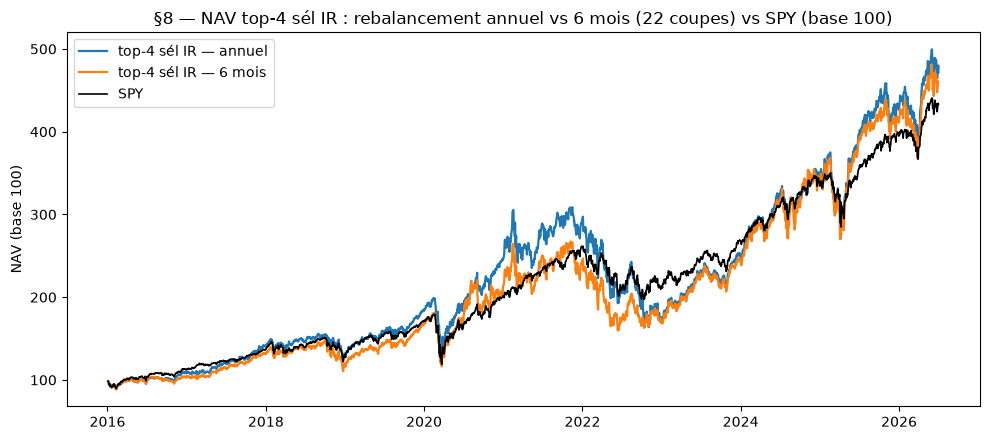

In [31]:
# FIGURE : NAV rééquilibrage annuel vs 6 mois (top-4 sél IR) vs SPY, base commune
start = max(r_dr_eq.index.min(), r_6m_ir.index.min())
a = r_dr_eq[r_dr_eq.index >= start]; m = r_6m_ir[r_6m_ir.index >= start]
nav9_an = 100 * (1 + a).cumprod(); nav9_6m = 100 * (1 + m).cumprod()
ix = nav9_an.index.union(nav9_6m.index)
nav9_sp = 100 * (1 + r_spy.reindex(ix).fillna(0)).cumprod()
plt.figure(figsize=(10, 4.5))
plt.plot(nav9_an, label="top-4 sél IR — annuel", lw=1.6)
plt.plot(nav9_6m, label="top-4 sél IR — 6 mois", lw=1.6)
plt.plot(nav9_sp, label="SPY", color="k", lw=1.2)
plt.ylabel("NAV (base 100)"); plt.title(f"§8 — NAV top-4 sél IR : rebalancement annuel vs 6 mois ({len(cuts)} coupes) vs SPY (base 100)")
plt.legend(); plt.tight_layout(); plt.show()

## 9. Pondérer autrement que $1/K$ — inverse-vol, ERC, GMV

$$\underbrace{1/K}_{\sigma\ \text{égales},\ \rho=0}\ \subset\ \underbrace{\text{inverse-vol}}_{\sigma\ \text{libres},\ \rho=0}\ \subset\ \underbrace{\{\text{ERC},\ \text{GMV}\}}_{\Sigma\ \text{complète}}\ \subset\ \underbrace{\text{Markowitz}}_{+\,\mu}$$

**Cadre.** $K$ membres, $w=(w_k)$, **long-only** $w_k\ge0$, **investi** $\mathbf 1^\top w=1$ ; $\ \Sigma_{ij}=\rho_{ij}\sigma_i\sigma_j$, $\ \sigma_p^2=w^\top\Sigma\,w$. Tout ($\sigma_k,\Sigma$) est estimé **point-in-time** ($s\le t^R$) et appliqué à $Y{+}1$. Le moteur en parts (§6.1) est inchangé : seul $w$ change.

**Inverse-vol** — $\sigma_k$ seuls, corrélations ignorées :
$$\boxed{\;w_k=\frac{1/\sigma_k}{\sum_{j}1/\sigma_j}\;}\qquad \sigma_k=\mathrm{std}\big(r_k(s)\big)_{s\le t^R}\,\sqrt{252}.$$

**ERC** — contributions au risque égales, $\ \mathrm{RC}_k=w_k(\Sigma w)_k$, $\ \sum_k\mathrm{RC}_k=w^\top\Sigma w$ :
$$\boxed{\;w_k(\Sigma w)_k=w_j(\Sigma w)_j\quad\forall k,j\;}$$

**GMV** — variance minimale, long-only :
$$\boxed{\;w^\star=\arg\min_{\mathbf 1^\top w=1,\;w\ge0}\ w^\top\Sigma\,w\;}\qquad\Big(\text{non contraint : }w^\star=\tfrac{\Sigma^{-1}\mathbf 1}{\mathbf 1^\top\Sigma^{-1}\mathbf 1}\ ;\quad \Sigma\ \text{diagonale}\Rightarrow w_k\propto 1/\sigma_k^2\Big)$$

Emboîtement : ERC $\to$ inverse-vol si $\rho$ constant $\to 1/K$ si $\Sigma=\sigma^2 I$.

| méthode | info utilisée | poids |
|---|---|---|
| $1/K$ | — | $1/K$ |
| inverse-vol | $\sigma_k$ | $\propto 1/\sigma_k$ |
| ERC | $\Sigma$ | $\mathrm{RC}_k$ égaux |
| GMV | $\Sigma$ | $\propto \Sigma^{-1}\mathbf 1$ |

In [32]:
# §9 — POIDS ALTERNATIFS : les primitives (fenêtre PIT, Σ, GMV, ERC, w_*) vivent dans
# tools.membre.moteur — exposées par l'amorçage. Estimation point-in-time (rendements <= tR).
print("poids alternatifs prets | inverse-vol, GMV, ERC (long-only, point-in-time, covariance d'échantillon)")


poids alternatifs prets | inverse-vol, GMV, ERC (long-only, point-in-time, covariance d'échantillon)


In [33]:
# §9 — orchestrateur : clone EXACT de strategie_en_parts (annuel), mais tR calcule par bloc -> weight_fn(bids, tR)
def strategie_ponderee(K, weight_fn, critere="ir"):
    blocs = []
    for Y in range(2015, 2026):
        sel = select_topK(Y, K, critere=critere)
        idx = cal[cal.year == (Y + 1)]
        if sel and len(idx):
            bids = [b for _, b in sel]
            tR = cal[cal.get_loc(idx[0]) - 1]            # coupe = veille du 1er jour tenu (IDENTIQUE au moteur)
            blocs.append((idx, bids, weight_fn(bids, tR)))
    return _parts_engine(blocs)

# GARDE-FOU de non-regression : w_equal doit reproduire les series 1/K du §6 bit-a-bit
assert np.allclose(strategie_ponderee(4, w_equal, "ir")["r"].values,        r_dr_eq.values), "w_equal != 1/K (IR)"
assert np.allclose(strategie_ponderee(4, w_equal, "appraisal")["r"].values, r_ap_eq.values), "w_equal != 1/K (appraisal)"
print("orchestrateur OK | w_equal reproduit exactement le portefeuille 1/K du §6 (les nouvelles ponderations ne changent QUE le vecteur w)")

orchestrateur OK | w_equal reproduit exactement le portefeuille 1/K du §6 (les nouvelles ponderations ne changent QUE le vecteur w)


In [34]:
# §9 — SANITY maths sur l'exemple de la note (sigma = 12/18/36 %) : les identites doivent tenir
_s  = np.array([.12, .18, .36])
_iv = (1 / _s) / (1 / _s).sum()
assert np.allclose(_iv, [.5, 1/3, 1/6], atol=1e-3)                                   # inverse-vol = 50/33/17 %
assert np.allclose(_iv * _s, (_iv * _s)[0], atol=1e-6)                               # budget de risque EGAL si rho=0
assert np.allclose(_gmv_from_cov(np.diag(_s ** 2)), (1/_s**2)/(1/_s**2).sum(), atol=2e-3)  # GMV_rho0 -> inverse-VARIANCE
for _rho in (0., .4, .8):                                                            # ERC -> inverse-vol si rho constant
    _Sig = np.outer(_s, _s) * ((1 - _rho) * np.eye(3) + _rho)
    assert np.allclose(_erc_from_cov(_Sig, _iv), _iv, atol=3e-3)
assert np.allclose(_erc_from_cov(np.eye(3), np.ones(3)/3), [1/3, 1/3, 1/3], atol=1e-3)     # sigma EGAL -> 1/K
_gmv_A = ((1/_s**2)/(1/_s**2).sum())[0]
print(f"sanity OK | membre calme A : 1/K {1/3:.3f} -> inverse-vol {_iv[0]:.3f} -> GMV_rho0 {_gmv_A:.3f}  (note: 0,333 / 0,500 / 0,643)")

sanity OK | membre calme A : 1/K 0.333 -> inverse-vol 0.500 -> GMV_rho0 0.643  (note: 0,333 / 0,500 / 0,643)


### 9.1 Résultat top-4 (annuel, puis 6 mois)

Base = **top-4 fixe** du §6.3 ($K=4$ — **pas** le $K$ walk-forward du §7) ; sélection des membres = classements point-in-time du §5 ; on ne change que $w$. Annuel : 11 années, seuil $t_{10}\approx1{,}81$ ; 6 mois : 22 semestres, seuil $\approx1{,}72$ (§8). Colonnes = §6.3/§7.

In [35]:
# §9 — series top-4 (annuel) par ponderation x critere de selection, puis TABLE (format identique §6.3/§7)
_paires = [("inverse-vol", w_invvol), ("ERC", w_erc), ("GMV", w_gmv)]
_ser = {("1/K", cr): (r_dr_eq if cr == "ir" else r_ap_eq) for cr in ("ir", "appraisal")}
for _nom, _fn in _paires:
    for _cr in ("ir", "appraisal"):
        _ser[(_nom, _cr)] = strategie_ponderee(4, _fn, _cr)["r"]

_cr_lbl = {"ir": "sel IR", "appraisal": "sel appr"}
print("top-4 fixe (K=4), rebalancement annuel — ponderation x critere de selection ; seuil t10 ≈ 1,81")
pd.DataFrame({f"{_nom} ({_cr_lbl[_cr]})": _ligne(_ser[(_nom, _cr)])
              for _cr in ("ir", "appraisal")
              for _nom in ["1/K", "inverse-vol", "ERC", "GMV"]}).T.round(3)

top-4 fixe (K=4), rebalancement annuel — ponderation x critere de selection ; seuil t10 ≈ 1,81


,exces_an,t,gagnantes,beta,alpha_ann,t_appr
1/K (sel IR),0.027909,0.797518,7/11,1.211435,-0.010845,-0.310296
inverse-vol (sel IR),0.03665,1.248386,7/11,1.178913,0.002978,0.112417
ERC (sel IR),0.033599,1.11028,7/11,1.177216,0.000159,0.005766
GMV (sel IR),0.031943,1.220283,6/11,1.104892,0.015169,0.479647
1/K (sel appr),-0.025324,-1.246978,3/11,1.009594,-0.02295,-0.757885
inverse-vol (sel appr),-0.027981,-1.42107,3/11,0.951374,-0.019845,-0.801397
ERC (sel appr),-0.032779,-1.664958,3/11,0.90952,-0.017949,-0.669965
GMV (sel appr),-0.044992,-2.762174,2/11,0.795363,-0.01011,-0.344306


In [36]:
# §9 — même tableau, mais rebalancement 6 MOIS (mêmes pondérations, coupes 30/06 & 31/12 du §8)
def strategie_ponderee_6m(K, weight_fn, critere="ir"):
    cache = clsmt6_ir if critere == "ir" else clsmt6_ap
    blocs = []
    for d in cuts:
        c = cache[d]
        if len(c) == 0:
            continue
        bids = list(c["bioguide_id"].head(K))
        idx = cal[(cal > d) & (cal <= next_bound(d))]
        if len(idx):
            tR = cal[cal.get_loc(idx[0]) - 1]          # coupe = veille du 1er jour tenu (comme l'annuel)
            blocs.append((idx, bids, weight_fn(bids, tR)))
    return _parts_engine(blocs)

# garde-fou : w_equal 6m reproduit exactement le 1/K semestriel du §8
assert np.allclose(strategie_ponderee_6m(4, w_equal, "ir")["r"].values,        r_6m_ir.values)
assert np.allclose(strategie_ponderee_6m(4, w_equal, "appraisal")["r"].values, r_6m_ap.values)

_ser6 = {("1/K", cr): (r_6m_ir if cr == "ir" else r_6m_ap) for cr in ("ir", "appraisal")}
for _nom, _fn in _paires:
    for _cr in ("ir", "appraisal"):
        _ser6[(_nom, _cr)] = strategie_ponderee_6m(4, _fn, _cr)["r"]
print(f"top-4 fixe (K=4), rebalancement 6 mois — ponderation x critere ; {eval_sem(r_6m_ir)['n']} semestres, seuil t ≈ 1,72")
pd.DataFrame({f"{_nom} ({_cr_lbl[_cr]})": _ligne6(_ser6[(_nom, _cr)])
              for _cr in ("ir", "appraisal")
              for _nom in ["1/K", "inverse-vol", "ERC", "GMV"]}).T.round(3)

top-4 fixe (K=4), rebalancement 6 mois — ponderation x critere ; 22 semestres, seuil t ≈ 1,72


,exces_an,t,gagnantes,beta,alpha_ann,t_appr
1/K (sel IR),0.005099,0.163757,12/22,1.244305,-0.024081,-0.622038
inverse-vol (sel IR),0.00577,0.206811,10/22,1.204833,-0.020831,-0.727326
ERC (sel IR),0.004882,0.176701,11/22,1.206584,-0.021377,-0.706805
GMV (sel IR),-0.002523,-0.119549,11/22,1.100818,-0.012976,-0.457999
1/K (sel appr),-0.050265,-2.00158,8/22,1.04774,-0.050658,-1.481685
inverse-vol (sel appr),-0.052397,-2.375902,5/22,0.985814,-0.047386,-1.781718
ERC (sel appr),-0.052861,-2.332823,8/22,0.946708,-0.042665,-1.481385
GMV (sel appr),-0.046845,-1.951257,6/22,0.808763,-0.020491,-0.696296


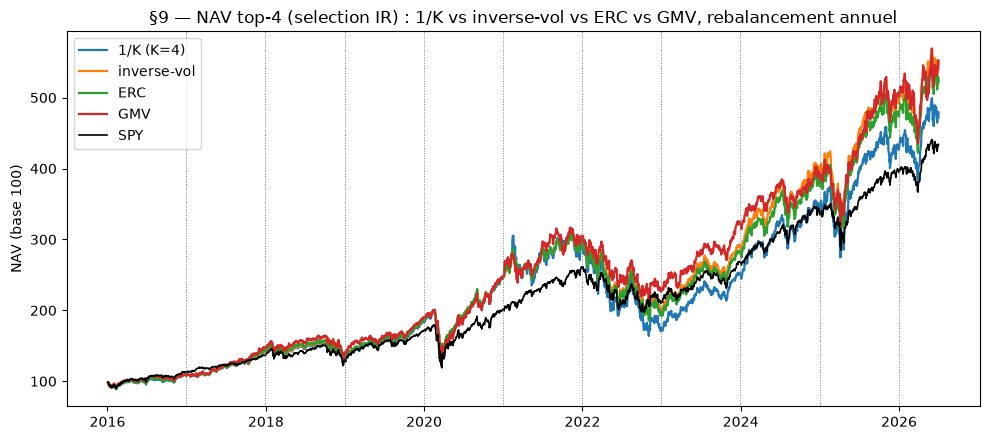

In [37]:
# §9 — FIGURE : NAV top-4 (selection IR) par ponderation, base 100 (pointilles = rebalancements annuels)
_nav = lambda r: 100 * (1 + r).cumprod()
plt.figure(figsize=(10, 4.5))
plt.plot(_nav(_ser[("1/K", "ir")]),         label="1/K (K=4)", lw=1.6)
plt.plot(_nav(_ser[("inverse-vol", "ir")]), label="inverse-vol", lw=1.6)
plt.plot(_nav(_ser[("ERC", "ir")]),         label="ERC", lw=1.6)
plt.plot(_nav(_ser[("GMV", "ir")]),         label="GMV", lw=1.6)
plt.plot(_nav(r_spy.reindex(_ser[("1/K", "ir")].index).fillna(0)), label="SPY", color="k", lw=1.2)
for j in det4["journal"][1:]:
    plt.axvline(j["rebal"], color="gray", ls=":", lw=0.7)
plt.ylabel("NAV (base 100)")
plt.title("§9 — NAV top-4 (selection IR) : 1/K vs inverse-vol vs ERC vs GMV, rebalancement annuel")
plt.legend(); plt.tight_layout(); plt.show()

### 9.2 Lecture

$$\max_{\text{pondérations}}\ t_{\rm appr}=+0{,}48\ \ll\ 1{,}645\ \ (\text{annuel comme 6 mois})\qquad\Longrightarrow\qquad \text{aucun }\alpha\text{ positif sous aucune pondération.}$$

- Les seuls $\lvert t_{\rm appr}\rvert>1{,}645$ sont **négatifs** (6 mois, sél appraisal : inverse-vol $-1{,}78$) — de la **sous-performance** ajustée, pas du talent.
- **inverse-vol** (sél IR, annuel) : seul gain net — $t:0{,}94\!\to\!1{,}49$, $\ \beta:1{,}20\!\to\!1{,}16$, $\ $excès $3{,}1\!\to\!4{,}0\,\%$/an. Risque mieux réparti, pas d'$\alpha$.
- **GMV** (sél appraisal, annuel) : $-4{,}5\,\%$/an, $t=-2{,}76$ — sur-ajustement de $\Sigma$ (DGU 2009).
- Verdict « $\beta$ de style, zéro $\alpha$ » **invariant** au choix de $w$ — comme le test IS/OS sur $K$ : ni *qui*, ni *combien*, ni *comment pondérer* n'est apprenable ici.

<!-- §10-MARKER -->
## 10. Robustesse d'estimation : $\Sigma$ shrinkée (Ledoit-Wolf)

Le §9 estime $\Sigma$ par la **covariance d'échantillon** brute $\hat\Sigma^{\text{emp}}$. À $K{=}4$ sur des fenêtres courtes, c'est **bruité** — et GMV, qui **inverse** $\Sigma$, amplifie ce bruit (§9.2 : GMV sél appr $-4{,}5\%/t\,{-}2{,}76$ = sur-ajustement ; DeMiguel–Garlappi–Uppal 2009). Le **shrinkage** régularise $\Sigma$ en la tirant vers une **cible stable** $F$ :

$$\boxed{\ \hat\Sigma^{\text{shrink}}=\delta\,F+(1-\delta)\,\hat\Sigma^{\text{emp}}\ }\qquad 0\le\delta\le 1,\qquad \hat\Sigma^{\text{emp}}_{ij}=\tfrac1T\textstyle\sum_{t\le t^R}(r_{t,i}-\bar r_i)(r_{t,j}-\bar r_j).$$

- $\delta=0\Rightarrow\hat\Sigma^{\text{emp}}$ (cov brute $=$ §9) ; $\ \delta=1\Rightarrow F$ (cible pure). **$\delta$ $=$ poids donné à la cible stable.**
- On ne change **que l'estimateur de $\Sigma$** : sélection walk-forward, moteur en parts (§6.1) et formules de poids (§9) **inchangés**. Point-in-time strict : $\hat\Sigma^{\text{emp}},F,\delta$ estimés sur $\{s\le t^R\}$, appliqués à $Y{+}1$.
- $1/K$ et inverse-vol n'utilisent que la **diagonale** ($\sigma_k$) $\Rightarrow$ **immunisés** ; seuls **ERC** et **GMV** (qui utilisent tout $\Sigma$) bougent.
- Shrinkage $=$ régularisation d'**estimation**, pas d'information $\Rightarrow$ il **ne peut pas créer d'$\alpha$** ; on teste s'il **dompte** l'artefact GMV.
- ⚠ Convention d'échelle (auditée) : le code recombine $\delta F+(1-\delta)\,\hat\Sigma^{\text{ddof}=1}$ (la cov
  brute du §9) alors que $F$ et $\delta$ sont estimés en convention $1/T$ ; l'écart $\approx(1-\delta)/T\sim0{,}2\,\%$
  des entrées est sans effet sur les poids (ERC/GMV invariants d'échelle) et garantit que $\delta=0$ reproduit
  le §9 bit-à-bit (validation 10.1-i).

### Le coefficient $\delta$ (intensité de shrinkage)

Ledoit–Wolf choisit $\delta$ **automatiquement**, comme un ratio *bruit / distance* :

$$\delta\ \approx\ \frac{\text{bruit de }\hat\Sigma^{\text{emp}}}{\text{distance entre }\hat\Sigma^{\text{emp}}\text{ et }F}\qquad\Longrightarrow\qquad \text{bruit élevé}\Rightarrow\delta\uparrow,\qquad F\ \text{loin}\Rightarrow\delta\downarrow.$$

Forme fermée (base commune aux cibles structurées), $T=$ nombre de jours communs :

$$\boxed{\ \delta=\frac{\pi-\rho}{T\,\gamma}\ }\qquad\text{puis}\qquad \delta\leftarrow\min\!\big(1,\ \max(0,\delta)\big),$$

$$\gamma=\big\lVert\hat\Sigma^{\text{emp}}-F\big\rVert_F^2\ \ (\text{distance à la cible}),\qquad \pi=\text{bruit total de }\hat\Sigma^{\text{emp}},\qquad \rho=\text{part du bruit déjà capturée par }F.$$

### Les trois cibles $F$

Même logique partout — **seule la cible $F$ change** (donc $\gamma$ et $\rho$). La diagonale a une forme simplifiée ; les deux autres passent par la base $\pi,\rho,\gamma$.

**Diagonale** (LW 2004) — variances moyennées, corrélations effacées :
$$F=\mu I,\quad \mu=\tfrac1K\operatorname{tr}\hat\Sigma^{\text{emp}}\ ;\qquad \delta_{\text{diag}}=\frac{b}{d},\quad d=\tfrac1K\!\sum_{i,j}(\hat\Sigma^{\text{emp}}_{ij})^2-\mu^2,\quad 0\le b\le d\ \text{(bruit estimé)}.$$

**Single-factor** (LW 2001) — un seul facteur commun, le « marché » $f_t=\tfrac1K\sum_k r_{t,k}$ :
$$F_{ij}=\beta_i\beta_j\,\sigma_f^2\ (i\neq j),\quad F_{ii}=\hat\Sigma^{\text{emp}}_{ii}\ ;\qquad \delta_{\text{1f}}=\frac{\pi-\rho_{\text{1f}}}{T\,\gamma_{\text{1f}}}.$$

**Corrélation constante** (LW 2003) — garde les $\sigma_k$, remplace toutes les corrélations par leur moyenne $\bar\rho=\tfrac{1}{K(K-1)}\sum_{i\neq j}\hat\rho_{ij}$ :
$$F_{ij}=\bar\rho\,\sqrt{\hat\Sigma^{\text{emp}}_{ii}\,\hat\Sigma^{\text{emp}}_{jj}}\ (i\neq j),\quad F_{ii}=\hat\Sigma^{\text{emp}}_{ii}\ ;\qquad \delta_{\text{cc}}=\frac{\pi-\rho_{\text{cc}}}{T\,\gamma_{\text{cc}}}.$$

La cellule de code ci-dessous calcule exactement ces $F$ et ces $\delta$ (`_lw_diagonal` / `_lw_single_factor` / `_lw_constant_correlation`), puis annualise $\hat\Sigma^{\text{shrink}}\!\times\!252$.

In [38]:
# §10 — CovarianceMatrixRecipes (LW multi-cibles) vit dans tools.membre.moteur — amorçage ;
# seul le rabat _w_shrunk (orchestration) reste ici.
def _w_shrunk(target, kind):
    """poids GMV/ERC calcules sur la Sigma shrinkee ; RABAT sur inverse-vol (§9) si fenetre courte / non-PSD."""
    def w(bids, tR):
        Sig, _ = _cov_pit_shrunk(bids, tR, target)
        if Sig is None or not CovarianceMatrixRecipes._is_positive_semidefinite(Sig):
            return w_invvol(bids, tR)
        return _gmv_from_cov(Sig) if kind == "gmv" else _erc_from_cov(Sig, w_invvol(bids, tR))
    return w

print("§10 pret | 4 estimateurs de Sigma : cov brute (= §9), Ledoit-Wolf {diagonal, single-factor, constant-corr}")

§10 pret | 4 estimateurs de Sigma : cov brute (= §9), Ledoit-Wolf {diagonal, single-factor, constant-corr}


### 10.1 Validation

Quatre contrôles avant de lire les tables :

$$\text{(i)}\quad w^{\text{sample}}_{\rm GMV/ERC}\equiv w^{\S9}_{\rm GMV/ERC}\ \ (\alpha{=}0\Rightarrow\hat\Sigma{=}S)\ ;\qquad \text{(ii)}\quad w_{1/K},\,w_{\text{inv-vol}}\ \text{inchangés (diagonale seule)}.$$

$$\text{(iii)}\quad \delta^{\text{diag}}\ \overset{!}{=}\ \texttt{sklearn.LedoitWolf.shrinkage\_}\ \ (\text{oracle tiers, même estimateur LW 2004, code indépendant})\ ;\qquad \text{(iv)}\quad \text{sanity synthétique}:\ T\!\gg\!K\Rightarrow\delta\!\to\!0,\ \ \rho\ \text{constant}\Rightarrow\text{ERC}=\text{inv-vol}.$$

In [39]:
# §10.1 — VALIDATION (contrôles avant lecture ; l'oracle sklearn confirme le LW 2004 codé plus haut)
from sklearn.covariance import LedoitWolf   # implémentation TIERCE et indépendante de Ledoit-Wolf (cible identité)

# (i) contrôle : cible "sample" (alpha=0) == cov brute du §9  ->  GMV/ERC identiques bit-a-bit
for _cr in ("ir", "appraisal"):
    assert np.allclose(strategie_ponderee(4, _w_shrunk("sample", "gmv"), _cr)["r"].values, _ser[("GMV", _cr)].values, atol=1e-9)
    assert np.allclose(strategie_ponderee(4, _w_shrunk("sample", "erc"), _cr)["r"].values, _ser[("ERC", _cr)].values, atol=1e-9)
# (ii) immunite : 1/K et inverse-vol ne touchent que la diagonale  ->  inchanges vs §9
assert np.allclose(strategie_ponderee(4, w_invvol, "ir")["r"].values, _ser[("inverse-vol", "ir")].values)
assert np.allclose(strategie_ponderee(4, w_equal,  "ir")["r"].values, r_dr_eq.values)
# (iii) oracle tiers : notre intensite LW-diagonal == sklearn.LedoitWolf.shrinkage_ (a la precision machine)
_dmax = 0.0
for _Y in range(2016, 2026):
    _s = select_topK(_Y, 4, "appraisal"); _idx = cal[cal.year == _Y + 1]
    if not _s or not len(_idx): continue
    _b = [b for _, b in _s]; _tR = cal[cal.get_loc(_idx[0]) - 1]; _R = _fenetre_pit(_b, _tR)
    if len(_R) < RISK_WINDOW_MIN: continue
    _, _aA = CovarianceMatrixRecipes(_R)._lw_diagonal()
    _dmax = max(_dmax, abs(_aA - LedoitWolf().fit(_R.values).shrinkage_))
assert _dmax < 1e-6
# (iv) sanity synthetique deterministe : echantillon riche -> shrinkage faible ; correlation constante -> ERC = inverse-vol
_rng = np.random.default_rng(0); _sig = np.array([.12, .18, .36]) / np.sqrt(252); _rho = 0.5
_L = np.linalg.cholesky(np.outer(_sig, _sig) * (_rho * np.ones((3, 3)) + (1 - _rho) * np.eye(3)))
_X = pd.DataFrame(_rng.standard_normal((4000, 3)) @ _L.T, columns=list("abc"))
_Scc, _ = CovarianceMatrixRecipes(_X).shrunk_covariance_matrix("ledoit_wolf", "constant_correlation")
_, _adiag = CovarianceMatrixRecipes(_X)._lw_diagonal()
_ivref = (1 / np.array([.12, .18, .36])) / (1 / np.array([.12, .18, .36])).sum()
assert _adiag < 0.05 and np.allclose(_erc_from_cov(_Scc, np.ones(3) / 3), _ivref, atol=2e-2)
print(f"validation OK | (i) sample≡§9 bit-a-bit | (ii) 1/K & inverse-vol immunises | "
      f"(iii) intensite LW-diag ≡ sklearn (max|Δ|={_dmax:.1e}) | (iv) sanity synthetique (α_diag={_adiag:.3f})")

validation OK | (i) sample≡§9 bit-a-bit | (ii) 1/K & inverse-vol immunises | (iii) intensite LW-diag ≡ sklearn (max|Δ|=4.2e-17) | (iv) sanity synthetique (α_diag=0.001)


### 10.2 Résultat top-4 (annuel, puis 6 mois)

Base identique au §9.1 : **top-4 fixe** ($K=4$), annuel puis 6 mois, mêmes seuils ($t_{10}\approx1{,}81$ ; $t\approx1{,}72$) — **on ne change que l'estimateur de $\Sigma$**. Seuls **ERC** et **GMV** dépendent de $\Sigma$ ; $1/K$ et inverse-vol (diagonale seule) sont **immunisés** — identiques au §9, donc omis ici (cf. §10.1). Ligne **cov brute** $=$ §9 (baseline). Colonnes $=$ §6.3/§9.

⚠ $t=(\bar x/s_x)\sqrt{n}$ dépend aussi de la **dispersion** $s_x$ des excès par période (§6.2) : deux lignes d'excès moyen proche peuvent avoir des $t$ différents.

In [40]:
# §10.2 — TABLE ANNUELLE : {ERC, GMV} x {cov brute (= §9), LW diag, LW 1-facteur, LW corr-const} + temoins immunises
_EST = [("cov brute", "sample"), ("LW diag", "LW-diag"), ("LW 1-fac", "LW-1fac"), ("LW corr-cst", "LW-cc")]
# seuls ERC et GMV dependent de Σ ; 1/K & inverse-vol (diagonale) sont immunises (= §9) -> pas dans le tableau
_ser10 = {}
for _cr in ("ir", "appraisal"):
    for _kind, _KL in [("erc", "ERC"), ("gmv", "GMV")]:
        for _lab, _tgt in _EST:
            _ser10[(_cr, f"{_KL} · {_lab}")] = (_ser[(_KL, _cr)] if _tgt == "sample"
                                                else strategie_ponderee(4, _w_shrunk(_tgt, _kind), _cr)["r"])
_ORDER = [f"{_KL} · {_lab}" for _KL in ("ERC", "GMV") for _lab, _ in _EST]
_ix = pd.MultiIndex.from_tuples([("sel IR" if _cr == "ir" else "sel appr", _m)
                                 for _cr in ("ir", "appraisal") for _m in _ORDER])
print("top-4 annuel — pondération x estimateur de Σ ; seuil t10 ≈ 1,81 ; 'cov brute' = §9")
pd.DataFrame([_ligne(_ser10[("ir" if _s == "sel IR" else "appraisal", _m)]) for _s, _m in _ix], index=_ix)   # pleine précision (affichage harmonisé §9.1)

top-4 annuel — pondération x estimateur de Σ ; seuil t10 ≈ 1,81 ; 'cov brute' = §9


exces_an         t gagnantes      beta  alpha_ann  \
sel IR   ERC · cov brute    0.033599  1.110280      7/11  1.177216   0.000159   
         ERC · LW diag      0.033139  1.095982      7/11  1.177929  -0.000336   
         ERC · LW 1-fac     0.033603  1.110373      7/11  1.177245   0.000158   
         ERC · LW corr-cst  0.033882  1.117404      7/11  1.178079   0.000231   
         GMV · cov brute    0.031943  1.220283      6/11  1.104892   0.015169   
         GMV · LW diag      0.029746  1.168131      5/11  1.104600   0.012881   
         GMV · LW 1-fac     0.031988  1.221078      6/11  1.105037   0.015185   
         GMV · LW corr-cst  0.032301  1.226163      5/11  1.108030   0.014998   
sel appr ERC · cov brute   -0.032779 -1.664958      3/11  0.909520  -0.017949   
         ERC · LW diag     -0.032291 -1.644894      3/11  0.913745  -0.017950   
         ERC · LW 1-fac    -0.032771 -1.665201      3/11  0.909591  -0.017952   
         ERC · LW corr-cst -0.032552 -1.669908      3/11  0.910551  -0.017914   
         GMV · cov brute   -0.044992 -2.762174      2/11  0.795363  -0.010110   
         GMV · LW diag     -0.042765 -2.466188      2/11  0.799417  -0.009046   
         GMV · LW 1-fac    -0.045049 -2.766515      2/11  0.795242  -0.010137   
         GMV · LW corr-cst -0.044699 -2.745422      2/11  0.794762  -0.009740   

                              t_appr  
sel IR   ERC · cov brute    0.005766  
         ERC · LW diag     -0.012132  
         ERC · LW 1-fac     0.005710  
         ERC · LW corr-cst  0.008373  
         GMV · cov brute    0.479647  
         GMV · LW diag      0.424607  
         GMV · LW 1-fac     0.480056  
         GMV · LW corr-cst  0.469959  
sel appr ERC · cov brute   -0.669965  
         ERC · LW diag     -0.664537  
         ERC · LW 1-fac    -0.670199  
         ERC · LW corr-cst -0.671334  
         GMV · cov brute   -0.344306  
         GMV · LW diag     -0.318805  
         GMV · LW 1-fac    -0.345080  
         GMV · LW corr-cst -0.331949

In [41]:
# §10.2 — MÊME TABLE, rebalancement 6 MOIS (coupes 30/06 & 31/12 du §8 ; via strategie_ponderee_6m du §9)
_ser10_6 = {}                                              # idem : ERC & GMV seuls (1/K & inverse-vol immunises)
for _cr in ("ir", "appraisal"):
    for _kind, _KL in [("erc", "ERC"), ("gmv", "GMV")]:
        for _lab, _tgt in _EST:
            _ser10_6[(_cr, f"{_KL} · {_lab}")] = strategie_ponderee_6m(4, _w_shrunk(_tgt, _kind), _cr)["r"]
print(f"top-4 6 mois — pondération x estimateur ; {eval_sem(r_6m_ir)['n']} semestres, seuil t ≈ 1,72")
pd.DataFrame([_ligne6(_ser10_6[("ir" if _s == "sel IR" else "appraisal", _m)]) for _s, _m in _ix], index=_ix)   # pleine précision (affichage harmonisé §9.1)

top-4 6 mois — pondération x estimateur ; 22 semestres, seuil t ≈ 1,72


exces_an         t gagnantes      beta  alpha_ann  \
sel IR   ERC · cov brute    0.004882  0.176701     11/22  1.206584  -0.021377   
         ERC · LW diag      0.004627  0.167226     11/22  1.207460  -0.021683   
         ERC · LW 1-fac     0.004887  0.176912     11/22  1.206600  -0.021375   
         ERC · LW corr-cst  0.005128  0.185631     11/22  1.207302  -0.021267   
         GMV · cov brute   -0.002523 -0.119549     11/22  1.100818  -0.012976   
         GMV · LW diag     -0.005490 -0.266067     12/22  1.104779  -0.016399   
         GMV · LW 1-fac    -0.002547 -0.120668     11/22  1.100911  -0.013010   
         GMV · LW corr-cst -0.004178 -0.200409     10/22  1.103218  -0.014697   
sel appr ERC · cov brute   -0.052861 -2.332823      8/22  0.946708  -0.042665   
         ERC · LW diag     -0.053042 -2.327418      8/22  0.950991  -0.043279   
         ERC · LW 1-fac    -0.052866 -2.333719      8/22  0.946774  -0.042678   
         ERC · LW corr-cst -0.052807 -2.343919      8/22  0.947840  -0.042763   
         GMV · cov brute   -0.046845 -1.951257      6/22  0.808763  -0.020491   
         GMV · LW diag     -0.049440 -2.220557      8/22  0.815761  -0.023401   
         GMV · LW 1-fac    -0.046964 -1.956743      6/22  0.808653  -0.020585   
         GMV · LW corr-cst -0.046479 -1.946729      7/22  0.809129  -0.020174   

                              t_appr  
sel IR   ERC · cov brute   -0.706805  
         ERC · LW diag     -0.714218  
         ERC · LW 1-fac    -0.706837  
         ERC · LW corr-cst -0.704910  
         GMV · cov brute   -0.457999  
         GMV · LW diag     -0.601393  
         GMV · LW 1-fac    -0.459193  
         GMV · LW corr-cst -0.516954  
sel appr ERC · cov brute   -1.481385  
         ERC · LW diag     -1.491937  
         ERC · LW 1-fac    -1.482262  
         ERC · LW corr-cst -1.491383  
         GMV · cov brute   -0.696296  
         GMV · LW diag     -0.831935  
         GMV · LW 1-fac    -0.699347  
         GMV · LW corr-cst -0.687578

In [42]:
# §10 — DIAGNOSTICS d'ESTIMATION (GMV, l'estimateur sensible) : intensite alpha, conditionnement, concentration, replis
def _diag_gmv(cr):
    out = {}
    for _lab, _tgt in _EST:
        ns, al, cs, csh, rep, mw, hh = [], [], [], [], 0, [], []
        for Y in range(2015, 2026):
            sel = select_topK(Y, 4, critere=cr); idx = cal[cal.year == (Y + 1)]
            if not sel or not len(idx): continue
            bids = [b for _, b in sel]; tR = cal[cal.get_loc(idx[0]) - 1]
            R = _fenetre_pit(bids, tR); ns.append(len(R))
            cs.append(np.linalg.cond(np.cov(R.values, rowvar=False) * 252))
            Sig, a = _cov_pit_shrunk(bids, tR, _tgt)
            if Sig is None:
                rep += 1; w = w_invvol(bids, tR)
            else:
                al.append(a); csh.append(np.linalg.cond(Sig)); w = _gmv_from_cov(Sig)
            mw.append(w.max()); hh.append((w ** 2).sum())
        out[_lab] = dict(T_moy=np.mean(ns), delta_LW=np.mean(al) if al else 0.0, cond_brute=np.mean(cs),
                         cond_shrink=np.mean(csh) if csh else np.mean(cs), replis=rep,
                         max_w=np.mean(mw), HHI=np.mean(hh))
    return pd.DataFrame(out).T.round(3)
print("GMV — diagnostics par estimateur (moyennes sur les coupes) : delta_LW=intensité δ, cond=conditionnement de Σ, HHI=concentration")
pd.concat({"sel IR": _diag_gmv("ir"), "sel appr": _diag_gmv("appraisal")})

GMV — diagnostics par estimateur (moyennes sur les coupes) : delta_LW=intensité δ, cond=conditionnement de Σ, HHI=concentration


T_moy  delta_LW  cond_brute  cond_shrink  replis  \
sel IR   cov brute    484.636     0.000      46.628       46.628     0.0   
         LW diag      484.636     0.051      46.628       30.673     0.0   
         LW 1-fac     484.636     0.009      46.628       46.612     0.0   
         LW corr-cst  484.636     0.399      46.628       39.139     0.0   
sel appr cov brute    514.727     0.000      50.227       50.227     0.0   
         LW diag      514.727     0.045      50.227       24.789     0.0   
         LW 1-fac     514.727     0.014      50.227       49.907     0.0   
         LW corr-cst  514.727     0.224      50.227       40.470     0.0   

                      max_w    HHI  
sel IR   cov brute    0.730  0.654  
         LW diag      0.690  0.601  
         LW 1-fac     0.731  0.655  
         LW corr-cst  0.737  0.666  
sel appr cov brute    0.767  0.674  
         LW diag      0.681  0.553  
         LW 1-fac     0.767  0.675  
         LW corr-cst  0.747  0.645

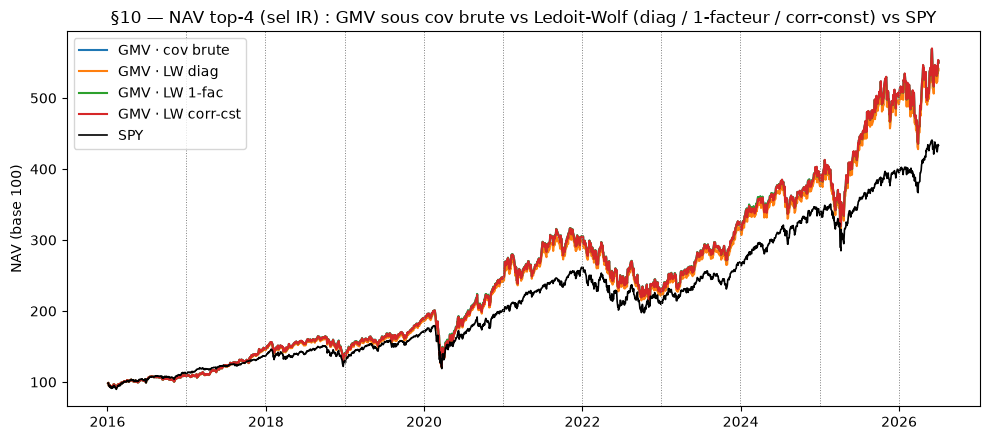

In [43]:
# §10 — FIGURE : NAV top-4 (sel IR) GMV par estimateur de Σ, base 100 (pointilles = rebalancements annuels)
_nav = lambda r: 100 * (1 + r).cumprod()
plt.figure(figsize=(10, 4.5))
for _lab, _tgt in _EST:
    plt.plot(_nav(_ser10[("ir", f"GMV · {_lab}")]), lw=1.5, label=f"GMV · {_lab}")
plt.plot(_nav(r_spy.reindex(_ser10[("ir", "GMV · cov brute")].index).fillna(0)), color="k", lw=1.2, label="SPY")
for j in det4["journal"][1:]:
    plt.axvline(j["rebal"], color="gray", ls=":", lw=0.7)
plt.ylabel("NAV (base 100)")
plt.title("§10 — NAV top-4 (sel IR) : GMV sous cov brute vs Ledoit-Wolf (diag / 1-facteur / corr-const) vs SPY")
plt.legend(); plt.tight_layout(); plt.show()

### 10.3 Lecture

$$\max_{\text{estimateurs}} t_{\rm appr}=+0{,}48\ \ll\ 1{,}645\qquad\Longrightarrow\qquad\text{aucun }\alpha\text{ positif réplicable sous tout estimateur de }\Sigma.$$

- **Le shrinkage dompte l'artefact GMV** (sél appr) : cov brute $-4{,}5\%/t\,{-}2{,}76\ \to\ -4{,}3\%/t\,{-}2{,}46$ (LW-diag) ; $\operatorname{cond}\Sigma\ 50\!\to\!25$, $\max_k w_k\ 0{,}77\!\to\!0{,}68$, HHI $0{,}67\!\to\!0{,}55$, intensité $\delta_{\rm LW}\approx0{,}05$. Artefact **tempéré**, pas inversé en talent.
- **Single-factor $\approx$ cov brute** ($\delta_{\rm LW}\approx0{,}01$, $\operatorname{cond}$ inchangé) : $K{=}4$ NAV de membres $=$ déjà **un seul facteur** (le marché) $\Rightarrow$ rien à shrinker vers un facteur.
- **Les seuls $\lvert t_{\rm appr}\rvert>1{,}645$ sont négatifs** (sous-performance ajustée des paniers sél-appraisal à 6 mois, ex. inverse-vol $t\,{-}1{,}78$) — **hérités du §9**, ni créés ni corrigés par le shrinkage.
- **Témoins** ($1/K$, inverse-vol) **identiques au §9** $\Rightarrow$ l'effet observé est bien dû à l'**estimation de $\Sigma$** seule.
- **Verdict invariant** : « $\beta$ de style $\approx1{,}20$, zéro $\alpha$ » — au *qui* (§4-5), *combien* (§7), *comment pondérer* (§9), et *comment estimer $\Sigma$* (§10).

<!-- PARTIE2-MARKER -->
# Partie II — Changement de règle : classement par le Sharpe

La Partie I sélectionnait les membres **significatifs** (IR ou appraisal, $t>1{,}645$) ; leur copie n'a produit aucun $\alpha$. On change de règle :
- on classe par le **Sharpe brut** (§2), $\mathrm{Sharpe}=\dfrac{\overline{r_P}}{\sigma(r_P)}\sqrt{252}$ — **plus aucun test de significativité** ;
- éligibilité : $n_{\text{days}}\ge126$ **et** $\mathrm{Sharpe}>0{,}4$ (le minimum de 10 trades saute) ;
- on copie le top-$K$ et on regarde ce que donnent **plusieurs $K$** (5, 10, 20) et **plusieurs pondérations** $w$.

## 11. Sélection par le Sharpe
- Éligibles v2 : tout membre avec $n_{\text{days}}\ge126$ jours de track **et** $\mathrm{Sharpe}>0{,}4$ — aucune autre condition.
- Le tableau ci-dessous : le top-20 des Sharpe, calculés sur tout l'historique 2014-2026.
- Pour la copie (§12), le classement est recalculé **point-in-time** à chaque coupe (31/12 ; et 30/06 en plus pour la cadence 6 mois) : le Sharpe n'utilise que les jours $\le$ la coupe, et le filtre $\mathrm{Sharpe}>0{,}4$ s'applique à la coupe.

In [44]:
# Éligibilité v2 (n_days >= 126 ET Sharpe > 0,4) + classement rétrospectif par le Sharpe brut du §2
MIN_SHARPE = 0.4
base2 = tab[tab.n_days >= MIN_DAYS].copy()                 # porte de matière : 126 jours
base2["sharpe"] = [stats(wf_ret[b])["sharpe"] for b in base2.bioguide_id]
elig2 = base2[base2.sharpe > MIN_SHARPE].copy()            # porte de niveau : Sharpe > 0,4
M2 = len(elig2)
_r_spy14 = r_spy.reindex(cal[cal >= "2014-01-01"]).dropna()
SH_SPY = _r_spy14.mean() / _r_spy14.std() * np.sqrt(252)
print(f"{len(tab)} membres -> {len(base2)} à n_days >= {MIN_DAYS} -> {M2} éligibles v2 (Sharpe > {MIN_SHARPE}) | Partie I : {M} | Sharpe SPY 2014-2026 : {SH_SPY:.2f}")
elig2.sort_values("sharpe", ascending=False).head(20)[["name", "n_trades", "n_days", "sharpe"]].round(3).reset_index(drop=True)

266 membres -> 263 à n_days >= 126 -> 224 éligibles v2 (Sharpe > 0.4) | Partie I : 223 | Sharpe SPY 2014-2026 : 0.83


,name,n_trades,n_days,sharpe
0,John Fetterman,10,284,2.904
1,Katie Britt,24,306,2.022
2,Terri A. Sewell,4,308,1.899
3,John James,257,661,1.718
4,Morgan McGarvey,24,853,1.714
5,Ashley Moody,23,364,1.660
6,Bruce Westerman,208,336,1.579
7,David J. Taylor,195,353,1.531
8,Greg Stanton,186,694,1.481
9,Lisa McClain,1479,580,1.427


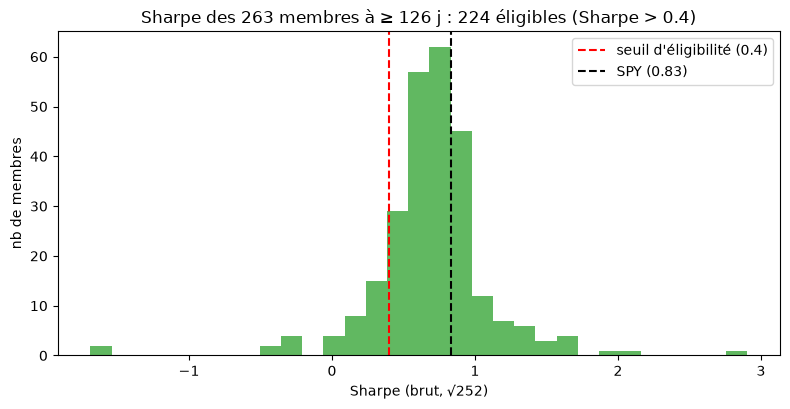

In [45]:
# FIGURE (style 4.1/4.2) : distribution des Sharpe (tous les >= 126 j), seuil d'éligibilité 0,4 et SPY en repères
plt.figure(figsize=(8, 4.2))
plt.hist(base2.sharpe.dropna(), bins=31, alpha=0.75, color="tab:green")
plt.axvline(MIN_SHARPE, color="red", ls="--", label=f"seuil d'éligibilité ({MIN_SHARPE})")
plt.axvline(SH_SPY, color="k", ls="--", label=f"SPY ({SH_SPY:.2f})")
plt.xlabel("Sharpe (brut, √252)"); plt.ylabel("nb de membres")
plt.title(f"Sharpe des {len(base2)} membres à ≥ {MIN_DAYS} j : {M2} éligibles (Sharpe > {MIN_SHARPE})")
plt.legend(); plt.tight_layout(); plt.show()

In [46]:
# Classement point-in-time par le SHARPE : n_days >= 126 ET Sharpe > 0,4 à la coupe — aucun test t
def classement_sharpe_a_date(d, min_days=MIN_DAYS, min_sharpe=MIN_SHARPE):
    rows = []
    for bid, r in wf_ret.items():
        rr = r.loc[:d]
        if len(rr) < min_days or rr.std() == 0:
            continue
        s = rr.mean() / rr.std() * np.sqrt(252)
        if s <= min_sharpe:
            continue
        rows.append(dict(bioguide_id=bid, score=s))
    return (pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
            if rows else pd.DataFrame(columns=["bioguide_id", "score"]))

clsmt_sh  = {Y: classement_sharpe_a_date(pd.Timestamp(f"{Y}-12-31")) for Y in range(2014, 2027)}
clsmt6_sh = {d: classement_sharpe_a_date(d) for d in cuts}
_nom = lambda c: df.loc[df.bioguide_id == c["bioguide_id"].iloc[0], "name"].iloc[0].split()[-1] if len(c) else "-"
resume_sh = pd.DataFrame([dict(fenetre=f"≤ {Y}", n_eligibles=len(clsmt_sh[Y]), tete=_nom(clsmt_sh[Y]),
                               sharpe_tete=round(float(clsmt_sh[Y]["score"].iloc[0]), 2) if len(clsmt_sh[Y]) else np.nan)
                          for Y in range(2014, 2027)])
print(f"classements Sharpe point-in-time prêts ({len(clsmt_sh)} coupes annuelles + {len(clsmt6_sh)} semestrielles) — n éligibles (Sharpe > {MIN_SHARPE}) et tête par coupe")
resume_sh

classements Sharpe point-in-time prêts (13 coupes annuelles + 22 semestrielles) — n éligibles (Sharpe > 0.4) et tête par coupe


,fenetre,n_eligibles,tete,sharpe_tete
0,≤ 2014,55,Jr.,2.52
1,≤ 2015,50,Sessions,1.49
2,≤ 2016,71,Long,2.88
3,≤ 2017,107,Khanna,3.50
4,≤ 2018,90,Speier,1.57
5,≤ 2019,146,Lee,2.78
6,≤ 2020,149,Wyden,2.50
7,≤ 2021,176,Case,2.35
8,≤ 2022,139,Trone,1.27
9,≤ 2023,174,Landsman,2.27


## 12. Copie top-$K$ × pondérations $w$
À chaque coupe, on copie les $K$ premiers du classement Sharpe et on les tient jusqu'à la coupe suivante — moteur en parts du §6.1, inchangé. Cinq pondérations :

| poids | formule | source |
|---|---|---|
| $1/K$ | $w_k=1/K$ | §6 |
| $\propto$Sharpe | $w_k=\max(S_k,0)\big/\sum_j\max(S_j,0)$, $S_k$ = Sharpe point-in-time | nouveau |
| inverse-vol | $w_k\propto1/\sigma_k$ | §9 |
| ERC | $\mathrm{RC}_k$ égaux | §9 |
| GMV | $\arg\min_{w\ge0,\ \mathbf 1^\top w=1}\ w^\top\Sigma\,w$ | §9 |

- $\propto$Sharpe est long-only par construction ; si tous les $S_k\le0$, on prend $1/K$.
- ERC et GMV estiment $\Sigma$ sur la **fenêtre commune** des $K$ membres (§9). Si elle fait moins de 60 jours (`RISK_WINDOW_MIN`, §10), on applique inverse-vol à la place ; ces cas sont comptés dans les tables (0 en pratique).

In [47]:
# §12 — poids ∝Sharpe + orchestrateur top-K Sharpe (annuel & 6 mois) ; rabat inverse-vol si fenêtre commune courte
_replis = []                                             # coupes où ERC/GMV se sont rabattus (fenêtre < RISK_WINDOW_MIN)

def w_sharpe(bids, tR):                                  # w_k ∝ max(S_k, 0), S_k = Sharpe point-in-time
    s = []
    for b in bids:
        r = wf_ret[b].loc[:tR]
        s.append(r.mean() / r.std() * np.sqrt(252) if r.std() > 0 else 0.0)
    s = np.clip(np.array(s), 0.0, None)
    return s / s.sum() if s.sum() > 0 else np.ones(len(bids)) / len(bids)

def _rabat_court(kind):
    # ERC/GMV du §9, mais : si < RISK_WINDOW_MIN jours communs (ou < 2 membres), repli inverse-vol (compté)
    def w(bids, tR):
        R = _fenetre_pit(bids, tR)
        if len(R) < RISK_WINDOW_MIN or R.shape[1] < 2:
            _replis.append(tR)
            return w_invvol(bids, tR)
        Sig = np.cov(R.values, rowvar=False) * 252
        return _gmv_from_cov(Sig) if kind == "gmv" else _erc_from_cov(Sig, w_invvol(bids, tR))
    return w

w_gmv_r, w_erc_r = _rabat_court("gmv"), _rabat_court("erc")

def strategie_sharpe(K, weight_fn, cadence="annuel"):
    """Top-K du classement SHARPE (aucun filtre), moteur en parts §6.1 ; cadence annuelle (31/12) ou "6m" (§8)."""
    blocs = []
    coupes = ([(pd.Timestamp(f"{Y}-12-31"), cal[cal.year == (Y + 1)]) for Y in range(2015, 2026)]
              if cadence == "annuel" else
              [(d, cal[(cal > d) & (cal <= next_bound(d))]) for d in cuts])
    for d, idx in coupes:
        c = clsmt_sh[d.year] if cadence == "annuel" else clsmt6_sh[d]
        if len(c) == 0 or not len(idx):
            continue
        bids = list(c["bioguide_id"].head(K))
        tR = cal[cal.get_loc(idx[0]) - 1]                # coupe = veille du 1er jour tenu (comme §6/§9)
        blocs.append((idx, bids, weight_fn(bids, tR)))
    return _parts_engine(blocs)

print("orchestrateur Sharpe prêt (annuel & 6 mois) | poids : 1/K, ∝Sharpe, inverse-vol, ERC, GMV (rabat si < 60 j communs)")

orchestrateur Sharpe prêt (annuel & 6 mois) | poids : 1/K, ∝Sharpe, inverse-vol, ERC, GMV (rabat si < 60 j communs)


### 12.1 Validation
- (i) $K{=}1$ : le portefeuille copie un seul membre $\Rightarrow$ sa série de rendement doit être identique à celle du membre, chaque année tenue.
- (ii) $w_{\propto\text{Sharpe}}$ : recomposition de la même formule sur les mêmes entrées — un contrôle de **déterminisme** (somme $=1$, tous $\ge0$), pas un test croisé ; les vrais tests croisés sont (i) et (iii).
- (iii) La tête du classement point-in-time à la dernière coupe $=$ la tête du tableau rétrospectif du §11, avec le même Sharpe.
- (iv) Les rabats ERC/GMV (fenêtre $<60$ j) sont comptés dans les tables du §12.2.

In [48]:
# §12.1 — VALIDATION (contrôles avant lecture)
# (i) K=1 : la stratégie en parts EST le membre en tête (rendements identiques sur chaque année tenue)
_r1 = strategie_sharpe(1, w_equal)["r"]
for _Y in range(2015, 2026):
    _c = clsmt_sh[_Y]
    if len(_c) == 0:
        continue
    _b = _c["bioguide_id"].iloc[0]; _idx = cal[cal.year == _Y + 1]
    assert np.allclose(_r1.reindex(_idx).values, wf_ret[_b].reindex(_idx).fillna(0.0).values, atol=1e-12), _Y
# (ii) w ∝ Sharpe : recalcul indépendant + somme 1 + long-only
_bids = list(clsmt_sh[2025]["bioguide_id"].head(4)); _tR = cal[cal.get_loc(cal[cal.year == 2026][0]) - 1]
_w = w_sharpe(_bids, _tR)
_s = np.clip([wf_ret[b].loc[:_tR].mean() / wf_ret[b].loc[:_tR].std() * np.sqrt(252) for b in _bids], 0, None)
assert np.allclose(_w, np.array(_s) / np.sum(_s)) and abs(_w.sum() - 1) < 1e-12 and (_w >= 0).all()
# (iii) cohérence §11/§12 : tête du classement à la dernière coupe == tête rétrospective (même Sharpe)
_e2 = elig2.sort_values("sharpe", ascending=False)
assert clsmt_sh[2026]["bioguide_id"].iloc[0] == _e2["bioguide_id"].iloc[0]
assert abs(float(clsmt_sh[2026]["score"].iloc[0]) - float(_e2["sharpe"].iloc[0])) < 1e-12
print("validation OK | (i) K=1 ≡ membre tête | (ii) w∝Sharpe recalculé indépendamment | (iii) PIT 2026 ≡ rétrospectif §11")

validation OK | (i) K=1 ≡ membre tête | (ii) w∝Sharpe recalculé indépendamment | (iii) PIT 2026 ≡ rétrospectif §11


### 12.2 Résultat (annuel, puis 6 mois)
Même évaluation qu'en Partie I : excès par année civile ($n=11$, seuil $t_{10}\approx1{,}81$), puis par semestre ($n=22$, seuil $t\approx1{,}72$), plus la régression quotidienne ($\beta$, $\alpha_{\text{ann}}$, $t_{\text{appr}}$).
Colonne ajoutée : le **Sharpe de la stratégie**, à comparer au Sharpe du SPY affiché au-dessus de la table **annuelle** ($0{,}87$ sur la fenêtre de tenue ; la table 6 mois, dont la tenue démarre en juillet 2015, n'affiche pas ce repère). Chaque table : $K\in\{5,10,20\}$ en blocs, les cinq $w$ par bloc.

In [49]:
# §12.2 — TABLE ANNUELLE : K ∈ {5, 10, 20} x {1/K, ∝Sharpe, inverse-vol, ERC, GMV} (sélection Sharpe)
_W12 = [("1/K", w_equal), ("∝Sharpe", w_sharpe), ("inverse-vol", w_invvol), ("ERC", w_erc_r), ("GMV", w_gmv_r)]
_K12 = [5, 10, 20]
_ligne_sh = lambda r: {**_ligne(r), "sharpe": stats(r)["sharpe"]}
_replis.clear()
_det12 = {(_K, _lab): strategie_sharpe(_K, _fn) for _K in _K12 for _lab, _fn in _W12}
_ser12 = {k: v["r"] for k, v in _det12.items()}
_rspy_ten = r_spy.reindex(_ser12[(20, "1/K")].index).dropna()
SH_SPY_TEN = _rspy_ten.mean() / _rspy_ten.std() * np.sqrt(252)
_ix12 = pd.MultiIndex.from_tuples([(f"K={_K}", _lab) for _K in _K12 for _lab, _ in _W12])
print(f"top-K Sharpe (annuel) — 11 années, seuil t10 ≈ 1,81 | Sharpe SPY (fenêtre de tenue) : {SH_SPY_TEN:.2f} | rabats ERC/GMV (< {RISK_WINDOW_MIN} j communs) : {len(_replis)}")
pd.DataFrame([_ligne_sh(_ser12[(_K, _lab)]) for _K in _K12 for _lab, _ in _W12], index=_ix12).round(3)

top-K Sharpe (annuel) — 11 années, seuil t10 ≈ 1,81 | Sharpe SPY (fenêtre de tenue) : 0.87 | rabats ERC/GMV (< 60 j communs) : 0


exces_an      t gagnantes   beta  alpha_ann  t_appr  sharpe
K=5  1/K             0.035  1.096      6/11  1.057      0.018   0.756   0.898
     ∝Sharpe         0.036  1.055      6/11  1.061      0.018   0.762   0.898
     inverse-vol     0.024  0.946      6/11  1.016      0.015   0.696   0.893
     ERC             0.024  0.901      6/11  1.006      0.017   0.701   0.889
     GMV            -0.011 -0.392      4/11  0.861      0.008   0.271   0.788
K=10 1/K             0.007  0.410      5/11  1.019      0.002   0.085   0.836
     ∝Sharpe         0.016  0.782      6/11  1.028      0.008   0.400   0.868
     inverse-vol    -0.012 -0.880      4/11  0.885      0.003   0.174   0.848
     ERC            -0.025 -1.289      4/11  0.783      0.006   0.259   0.813
     GMV            -0.061 -2.067      3/11  0.526      0.011   0.431   0.750
K=20 1/K             0.000  0.008      6/11  1.019     -0.006  -0.355   0.813
     ∝Sharpe         0.006  0.388      6/11  1.024     -0.001  -0.051   0.838
     inverse-vol    -0.014 -1.240      5/11  0.900     -0.002  -0.127   0.833
     ERC            -0.031 -1.936      4/11  0.762      0.002   0.091   0.797
     GMV            -0.065 -2.621      4/11  0.453      0.014   0.665   0.796

In [50]:
# §12.2 — MÊME TABLE, rebalancement 6 MOIS (coupes 30/06 & 31/12 du §8)
_ligne6_sh = lambda r: {**_ligne6(r), "sharpe": stats(r)["sharpe"]}
_replis.clear()
_ser12_6 = {(_K, _lab): strategie_sharpe(_K, _fn, "6m")["r"] for _K in _K12 for _lab, _fn in _W12}
_n6 = eval_sem(_ser12_6[(20, "1/K")])["n"]
print(f"top-K Sharpe (6 mois) — {_n6} semestres, seuil t ≈ 1,72 | rabats ERC/GMV (< {RISK_WINDOW_MIN} j communs) : {len(_replis)}")
pd.DataFrame([_ligne6_sh(_ser12_6[(_K, _lab)]) for _K in _K12 for _lab, _ in _W12], index=_ix12).round(3)

top-K Sharpe (6 mois) — 22 semestres, seuil t ≈ 1,72 | rabats ERC/GMV (< 60 j communs) : 0


exces_an      t gagnantes   beta  alpha_ann  t_appr  sharpe
K=5  1/K            -0.007 -0.231      8/22  1.055     -0.016  -0.559   0.670
     ∝Sharpe        -0.000 -0.001     10/22  1.059     -0.011  -0.358   0.693
     inverse-vol    -0.019 -0.796      9/22  0.985     -0.018  -0.775   0.671
     ERC            -0.018 -0.723     10/22  0.963     -0.015  -0.582   0.680
     GMV            -0.055 -2.065      6/22  0.794     -0.025  -0.974   0.560
K=10 1/K            -0.010 -0.452     11/22  1.033     -0.015  -0.681   0.701
     ∝Sharpe        -0.001 -0.042     10/22  1.040     -0.008  -0.360   0.735
     inverse-vol    -0.029 -1.851      8/22  0.892     -0.015  -0.801   0.696
     ERC            -0.040 -2.290      7/22  0.787     -0.010  -0.415   0.674
     GMV            -0.069 -2.373      5/22  0.502      0.003   0.111   0.664
K=20 1/K            -0.013 -0.916     12/22  1.022     -0.016  -0.944   0.715
     ∝Sharpe        -0.006 -0.400     11/22  1.028     -0.011  -0.626   0.740
     inverse-vol    -0.026 -2.464      7/22  0.902     -0.013  -0.896   0.727
     ERC            -0.041 -3.136      6/22  0.765     -0.009  -0.413   0.694
     GMV            -0.063 -2.365      6/22  0.458      0.013   0.637   0.766

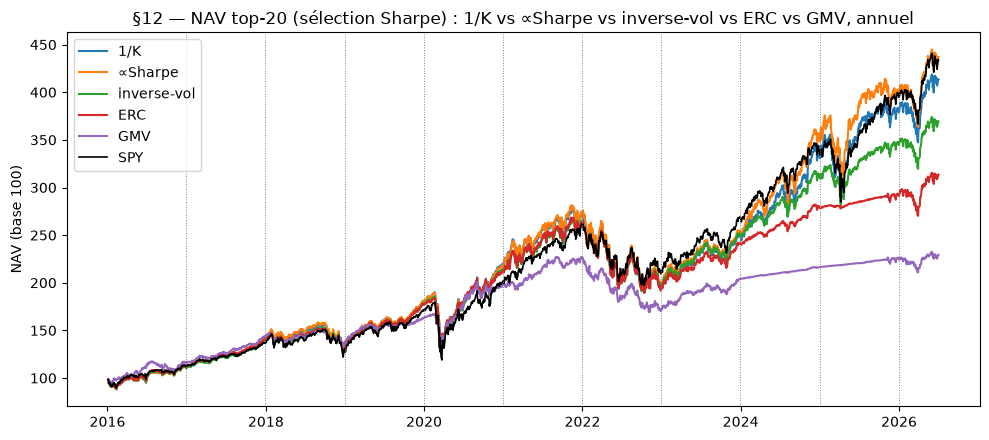

In [51]:
# §12 — FIGURE : NAV top-20 (sélection Sharpe) par pondération vs SPY, base 100 (pointillés = rebalancements)
_nav = lambda r: 100 * (1 + r).cumprod()
plt.figure(figsize=(10, 4.5))
for _lab, _ in _W12:
    plt.plot(_nav(_ser12[(20, _lab)]), lw=1.5, label=_lab)
plt.plot(_nav(r_spy.reindex(_ser12[(20, "1/K")].index).fillna(0)), color="k", lw=1.2, label="SPY")
for _j in _det12[(20, "1/K")]["journal"][1:]:
    plt.axvline(_j["rebal"], color="gray", ls=":", lw=0.7)
plt.ylabel("NAV (base 100)")
plt.title("§12 — NAV top-20 (sélection Sharpe) : 1/K vs ∝Sharpe vs inverse-vol vs ERC vs GMV, annuel")
plt.legend(); plt.tight_layout(); plt.show()

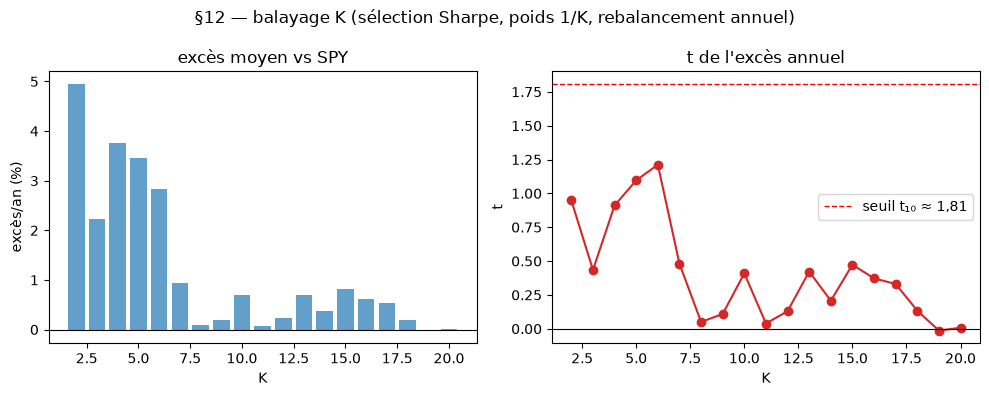

max du balayage : K=6 — excès +2.83 %/an, t = 1.212, t_appr = 0.985, Sharpe = 0.925, gagnantes 7/11 (> K=5 : t = 1,099 — c'est LUI le vrai max de la Partie II, toujours < 1,81)


In [52]:
# §12 — FIGURE : balayage K = 2..20 (poids 1/K, annuel) : excès/an et t en fonction de K
_Ks = list(range(2, 21))
_bal = [eval_yearly(strategie_sharpe(_K, w_equal)["r"]) for _K in _Ks]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.bar(_Ks, [100 * _b["exces_moyen"] for _b in _bal], color="tab:blue", alpha=0.7)
ax1.axhline(0, color="k", lw=0.8); ax1.set_xlabel("K"); ax1.set_ylabel("excès/an (%)"); ax1.set_title("excès moyen vs SPY")
ax2.plot(_Ks, [_b["t"] for _b in _bal], marker="o", color="tab:red")
ax2.axhline(1.81, color="red", ls="--", lw=1, label="seuil t₁₀ ≈ 1,81"); ax2.axhline(0, color="k", lw=0.8)
ax2.set_xlabel("K"); ax2.set_ylabel("t"); ax2.set_title("t de l'excès annuel"); ax2.legend()
fig.suptitle("§12 — balayage K (sélection Sharpe, poids 1/K, rebalancement annuel)")
plt.tight_layout(); plt.show()
_i6 = int(np.argmax([_b["t"] for _b in _bal]))
_l6 = _ligne_sh(strategie_sharpe(_Ks[_i6], w_equal)["r"])
print(f"max du balayage : K={_Ks[_i6]} — excès {100 * _l6['exces_an']:+.2f} %/an, t = {_l6['t']:.3f}, "
      f"t_appr = {_l6['t_appr']:.3f}, Sharpe = {_l6['sharpe']:.3f}, gagnantes {_l6['gagnantes']} "
      f"(> K=5 : t = 1,099 — c'est LUI le vrai max de la Partie II, toujours < 1,81)")

### 12.3 Lecture

$$\max_{K,\ w,\ \text{cadence}}\ t=1{,}212\ (K{=}6,\ \text{balayage}\ ;\ <1{,}81),\qquad \max\ t_{\text{appr}}=0{,}99\ (<1{,}645)\qquad\Longrightarrow\qquad \text{aucune configuration ne bat le SPY significativement.}$$

- Meilleur cas des **tables détaillées** : $K{=}5$, poids $1/K$, annuel — excès $+3{,}5\,\%$/an, $t=1{,}10$.
  Le **balayage** $K=2..20$ culmine à $K{=}6$ : excès $+2{,}8\,\%$/an, $t=1{,}212$, $t_{\text{appr}}=0{,}99$,
  Sharpe $0{,}93$ (imprimé sous la figure) — compatible avec le hasard lui aussi.
- Plus on copie large, moins il reste : $+3{,}5\,\%$/an ($K{=}5$) $\to$ $+0{,}7\,\%$ ($K{=}10$) $\to$ $-0{,}2\,\%$ ($K{=}20$).
- Le Sharpe du portefeuille (au mieux $0{,}93$ à $K{=}6$, $0{,}90$ à $K{=}5$) reste au niveau du SPY ($0{,}87$) : le couple rendement/risque n'est pas amélioré.
- Aucune pondération n'aide : $\propto$Sharpe $\approx1/K$ ; inverse-vol et ERC font moins bien ; GMV ($\beta$ $0{,}45$–$0{,}86$) perd $\approx6\,\%$/an faute d'exposition au marché, avec $\alpha\approx0$ — pas une perte de talent.
- À 6 mois : aucun excès positif ; les seuls $t$ au-delà du seuil sont négatifs (ex. ERC $K{=}20$ : $t=-3{,}21$).
- Sans filtre de significativité, les têtes de classement sont des historiques courts (Fetterman 284 j, Sewell 4 trades) : un bon Sharpe sur si peu de jours ne se reproduit pas l'année suivante.
- Le seuil d'éligibilité $\mathrm{Sharpe}>0{,}4$ ne change **aucun** résultat du §12 (tables et figures identiques au chiffre près) : même à $K{=}20$, le classement ne descend jamais sous $0{,}4$ à une coupe — le seuil n'élague que la queue du classement (263 $\to$ 224 membres en rétrospectif).
- Conclusion : le classement par le Sharpe ne fait pas mieux que la Partie I — pas d'$\alpha$.